# Required modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Run this cell in Colab to install libraries
!pip install torch torchvision torchaudio --quiet
!pip install timm --quiet
!pip install transformers --quiet
!pip install Pillow --quiet # For handling images
!pip install trimesh --quiet
!pip install pyglet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 709.3/709.3 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 984.0/984.0 kB 39.7 MB/s eta 0:00:00


# Single image to 3D

In [3]:
#@title Single image to 3d

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# import torch.nn.functional as F
# from PIL import Image
# import numpy as np
# import os
# import glob
# from tqdm import tqdm
# import time
# import trimesh
# import torchvision.transforms.functional as TF
# import math
# import matplotlib.pyplot as plt # Import for plotting

# try:
#     from transformers import AutoImageProcessor, AutoModel
# except ImportError:
#     print("Please install transformers: pip install transformers")
#     class DummyAutoImageProcessor:
#          @staticmethod
#          def from_pretrained(name): print(f"Warning: transformers not found. Using dummy processor for {name}."); return lambda images, return_tensors: {'pixel_values': torch.randn(1, 3, 224, 224)}
#     class DummyAutoModel:
#         @staticmethod
#         def from_pretrained(name): print(f"Warning: transformers not found. Using dummy encoder for {name}."); return nn.Identity()
#     AutoImageProcessor = DummyAutoImageProcessor
#     AutoModel = DummyAutoModel

# def mesh_to_triplane_voxel(mesh_path, output_resolution=256, voxel_resolution=128, normalize=True):
#     try:
#         if not os.path.exists(mesh_path):
#              return None
#         mesh = trimesh.load(mesh_path, force='mesh', process=False)
#         if isinstance(mesh, trimesh.Scene): mesh = mesh.dump(concatenate=True)
#         if not isinstance(mesh, trimesh.Trimesh):
#              return None
#         if len(mesh.vertices) == 0 or len(mesh.faces) == 0:
#             return None
#         try:
#             unique_faces = mesh.unique_faces(); mesh.update_faces(unique_faces)
#             mesh.remove_unreferenced_vertices()
#         except Exception as proc_e: print(f"Warning: Mesh proc error {mesh_path}: {proc_e}.")
#         if normalize:
#             try:
#                 center = mesh.bounds.mean(axis=0); mesh.apply_translation(-center)
#                 max_extent = np.ptp(mesh.bounds, axis=0).max()
#                 if max_extent > 1e-6: mesh.apply_scale(1.0 / max_extent)
#             except Exception as norm_e: print(f"Warning: Normalize error {mesh_path}: {norm_e}")
#         try:
#             pitch = 1.0 / voxel_resolution
#             voxel_grid = mesh.voxelized(pitch=pitch)
#             voxel_matrix = voxel_grid.matrix.astype(np.float32)
#             current_shape = voxel_matrix.shape
#             target_shape = (voxel_resolution, voxel_resolution, voxel_resolution)
#             padded_matrix = np.zeros(target_shape, dtype=np.float32)
#             min_shape = tuple(min(s, t) for s, t in zip(current_shape, target_shape))
#             padded_matrix[:min_shape[0], :min_shape[1], :min_shape[2]] = \
#                 voxel_matrix[:min_shape[0], :min_shape[1], :min_shape[2]]
#             voxel_matrix = padded_matrix
#         except Exception as vox_e: print(f"Error voxelizing {mesh_path}: {vox_e}"); return None
#         if voxel_matrix.sum() == 0:
#             return None

#         plane_xy = np.max(voxel_matrix, axis=2)
#         plane_yz = np.max(voxel_matrix, axis=0)
#         plane_xz = np.max(voxel_matrix, axis=1)

#         plane_xy_t = torch.from_numpy(plane_xy).unsqueeze(0).float()
#         plane_yz_t = torch.from_numpy(plane_yz).unsqueeze(0).float()
#         plane_xz_t = torch.from_numpy(plane_xz).unsqueeze(0).float()

#         target_size = (output_resolution, output_resolution)
#         plane_xy_t = F.interpolate(plane_xy_t.unsqueeze(0), size=target_size, mode='bilinear', align_corners=False).squeeze(0)
#         plane_yz_t = F.interpolate(plane_yz_t.unsqueeze(0), size=target_size, mode='bilinear', align_corners=False).squeeze(0)
#         plane_xz_t = F.interpolate(plane_xz_t.unsqueeze(0), size=target_size, mode='bilinear', align_corners=False).squeeze(0)

#         plane_xy_rgb = plane_xy_t.repeat(3, 1, 1)
#         plane_yz_rgb = plane_yz_t.repeat(3, 1, 1)
#         plane_xz_rgb = plane_xz_t.repeat(3, 1, 1)

#         triplane_tensor = torch.cat([plane_xy_rgb, plane_yz_rgb, plane_xz_rgb], dim=0)
#         triplane_tensor = torch.clamp(triplane_tensor, 0.0, 1.0)
#         return triplane_tensor
#     except Exception as e:
#         return None

# class ImageMeshToTriplaneDataset(Dataset):
#     def __init__(self, image_dir, mesh_dir, image_processor,
#                  triplane_resolution=256, voxel_grid_resolution=128):
#         self.image_dir = image_dir; self.mesh_dir = mesh_dir
#         self.image_processor = image_processor
#         self.triplane_resolution = triplane_resolution
#         self.voxel_grid_resolution = voxel_grid_resolution
#         self.mesh_ext = ".obj"; self.image_exts = (".jpg", ".png")
#         if not os.path.isdir(image_dir): raise FileNotFoundError(f"Image dir not found: {image_dir}")
#         if not os.path.isdir(mesh_dir): raise FileNotFoundError(f"Mesh dir not found: {mesh_dir}")
#         print(f"Scanning {image_dir} for {self.image_exts} files...")
#         all_image_paths = []
#         for ext in self.image_exts: all_image_paths.extend(glob.glob(os.path.join(image_dir, f"*{ext}")))
#         print(f"Scanning {mesh_dir} for {self.mesh_ext} files...")
#         all_mesh_paths = glob.glob(os.path.join(mesh_dir, f"*{self.mesh_ext}"))
#         image_map = {}; mesh_map = {}
#         for p in all_image_paths: base = os.path.splitext(os.path.basename(p))[0]; image_map[base] = p
#         for p in all_mesh_paths: base = os.path.splitext(os.path.basename(p))[0]; mesh_map[base] = p
#         print(f"Found {len(image_map)} unique image base names with extensions {self.image_exts}.")
#         print(f"Found {len(mesh_map)} unique mesh base names with extension {self.mesh_ext}.")
#         self.valid_files = sorted(list(image_map.keys() & mesh_map.keys()))
#         self.image_path_map = {base: image_map[base] for base in self.valid_files}
#         self.mesh_path_map = {base: mesh_map[base] for base in self.valid_files}
#         print(f"Found {len(self.valid_files)} matching image/mesh pairs ({'/'.join(self.image_exts)}/{self.mesh_ext}).")
#         if not self.valid_files: print(f"Warning: No matching pairs found!")

#     def __len__(self): return len(self.valid_files)

#     def __getitem__(self, idx):
#         if idx >= len(self.valid_files): raise IndexError("Index out of bounds")
#         base_name = self.valid_files[idx]
#         img_path = self.image_path_map.get(base_name)
#         mesh_path = self.mesh_path_map.get(base_name)
#         if img_path is None or mesh_path is None: raise RuntimeError(f"Path mapping missing for {base_name}")
#         try:
#             image = Image.open(img_path).convert("RGB")
#             processed_image = self.image_processor(images=image, return_tensors="pt")['pixel_values'].squeeze(0)
#             triplane_tensor = mesh_to_triplane_voxel(
#                 mesh_path,
#                 output_resolution=self.triplane_resolution,
#                 voxel_resolution=self.voxel_grid_resolution
#             )
#             if triplane_tensor is None:
#                 raise RuntimeError(f"Failed voxel triplane gen for {base_name}")
#             return processed_image, triplane_tensor
#         except Exception as e:
#             print(f"Error processing item {idx} ({base_name}): {e}. Skipping.")
#             raise e

# class PositionalEncoding2D(nn.Module):
#     def __init__(self, d_model, height, width):
#         super().__init__()
#         if d_model % 4 != 0:
#             raise ValueError("Cannot use sin/cos positional encoding with odd dimension (got dim={:d})".format(d_model))
#         pe = torch.zeros(d_model, height, width)
#         d_model_h = d_model // 2
#         d_model_w = d_model // 2
#         div_term = torch.exp(torch.arange(0., d_model_h, 2) * -(math.log(10000.0) / d_model_h))
#         pos_w = torch.arange(0., width).unsqueeze(1)
#         pos_h = torch.arange(0., height).unsqueeze(1)
#         pe[0:d_model_h:2, :, :] = torch.sin(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)
#         pe[1:d_model_h:2, :, :] = torch.cos(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)
#         pe[d_model_h::2, :, :] = torch.sin(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
#         pe[d_model_h+1::2, :, :] = torch.cos(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
#         self.register_buffer('pe', pe.unsqueeze(0))

#     def forward(self, x):
#         x = x + self.pe[:, :, :x.size(2), :x.size(3)]
#         return x

# class TriplaneDecoder(nn.Module):
#     def __init__(self, encoder_dim=768, decoder_dim=512, decoder_layers=4, decoder_heads=8,
#                  output_channels=9, output_resolution=256, input_patch_grid_res=16):
#         super().__init__()
#         self.encoder_dim = encoder_dim; self.decoder_dim = decoder_dim
#         self.output_resolution = output_resolution; self.input_patch_grid_res = input_patch_grid_res
#         self.num_patches = input_patch_grid_res * input_patch_grid_res
#         self.input_proj = nn.Linear(encoder_dim, decoder_dim)
#         self.pos_encoder = PositionalEncoding2D(decoder_dim, input_patch_grid_res, input_patch_grid_res)
#         decoder_layer = nn.TransformerDecoderLayer(
#             d_model=decoder_dim, nhead=decoder_heads, dim_feedforward=decoder_dim * 4,
#             dropout=0.1, activation=F.relu, batch_first=True)
#         self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=decoder_layers)
#         num_upsample_stages = int(math.log2(output_resolution // input_patch_grid_res))
#         if input_patch_grid_res * (2**num_upsample_stages) != output_resolution:
#              raise ValueError("Output resolution must be a power-of-2 multiple of input_patch_grid_res")
#         upsample_layers = []
#         current_dim = decoder_dim
#         for i in range(num_upsample_stages):
#             out_dim = current_dim // 2
#             upsample_layers.append(nn.Sequential(
#                 nn.ConvTranspose2d(current_dim, out_dim, kernel_size=4, stride=2, padding=1),
#                 nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True),
#                 nn.Conv2d(out_dim, out_dim, kernel_size=3, stride=1, padding=1),
#                 nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True)))
#             current_dim = out_dim
#         self.upsample_neck = nn.Sequential(*upsample_layers)
#         self.output_proj = nn.Conv2d(current_dim, output_channels, kernel_size=3, stride=1, padding=1)
#         self.output_activation = nn.Tanh()

#     def forward(self, patch_embeddings):
#         if patch_embeddings.shape[1] == self.num_patches + 1:
#              patch_embeddings = patch_embeddings[:, 1:, :]
#         elif patch_embeddings.shape[1] != self.num_patches:
#              raise ValueError(f"Input sequence length ({patch_embeddings.shape[1]}) does not match expected num_patches ({self.num_patches}) or num_patches+1.")
#         decoder_input_seq = self.input_proj(patch_embeddings)
#         batch_size = decoder_input_seq.shape[0]
#         spatial_input = decoder_input_seq.permute(0, 2, 1).reshape(
#             batch_size, self.decoder_dim, self.input_patch_grid_res, self.input_patch_grid_res)
#         spatial_input_with_pos = self.pos_encoder(spatial_input)
#         seq_with_pos = spatial_input_with_pos.flatten(2).permute(0, 2, 1)
#         refined_seq = self.transformer_decoder(tgt=seq_with_pos, memory=seq_with_pos)
#         spatial_features = refined_seq.permute(0, 2, 1).reshape(
#             batch_size, self.decoder_dim, self.input_patch_grid_res, self.input_patch_grid_res)
#         upsampled_features = self.upsample_neck(spatial_features)
#         output_logits = self.output_proj(upsampled_features)
#         output_triplane = self.output_activation(output_logits)
#         return output_triplane

# class ViTTriplaneGenerator(nn.Module):
#     def __init__(self, encoder_model_name="facebook/dinov2-base", decoder_dim=512, decoder_layers=4,
#                  decoder_heads=8, output_channels=9, output_resolution=256, input_patch_grid_res=16,
#                  freeze_encoder=True):
#         super().__init__()
#         self.encoder_model_name = encoder_model_name; self.output_resolution = output_resolution
#         self.output_channels = output_channels
#         print(f"Loading encoder: {encoder_model_name}...")
#         self.encoder = AutoModel.from_pretrained(encoder_model_name)
#         try: encoder_output_dim = self.encoder.config.hidden_size
#         except AttributeError: print("Warning: Assuming encoder_output_dim 768."); encoder_output_dim = 768
#         print(f"Encoder loaded. Output dimension assumed: {encoder_output_dim}")
#         self.decoder = TriplaneDecoder(
#             encoder_dim=encoder_output_dim, decoder_dim=decoder_dim, decoder_layers=decoder_layers,
#             decoder_heads=decoder_heads, output_channels=output_channels, output_resolution=output_resolution,
#             input_patch_grid_res=input_patch_grid_res)
#         if freeze_encoder: self.freeze_encoder()

#     def freeze_encoder(self):
#         print("Freezing encoder weights.")
#         for param in self.encoder.parameters(): param.requires_grad = False

#     def unfreeze_encoder(self):
#         print("Unfreezing encoder weights.")
#         for param in self.encoder.parameters(): param.requires_grad = True

#     def forward(self, pixel_values):
#         is_encoder_frozen = all(not p.requires_grad for p in self.encoder.parameters())
#         with torch.set_grad_enabled(not is_encoder_frozen):
#              encoder_outputs = self.encoder(pixel_values=pixel_values)
#         patch_embeddings = encoder_outputs.last_hidden_state
#         generated_triplane = self.decoder(patch_embeddings)
#         return generated_triplane, patch_embeddings

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {DEVICE}")

# TRAIN_IMAGE_DIR = "/content/drive/MyDrive/1_Diamond/BREP_Diff/Image_2D-3D_Source_folder/Dataset/Image"
# TRAIN_MESH_DIR = "/content/drive/MyDrive/1_Diamond/BREP_Diff/Image_2D-3D_Source_folder/Dataset/3dmodel"

# ENC_MODEL_NAME = "facebook/dinov2-base"
# DEC_DIM = 512
# DEC_LAYERS = 4
# DEC_HEADS = 8
# OUT_CH = 9
# OUT_RES = 256
# PATCH_GRID_RES = 16
# VOXEL_RES = 128

# LEARNING_RATE = 1e-4
# BATCH_SIZE = 8
# NUM_EPOCHS = 50
# WEIGHT_DECAY = 1e-5
# LR_STEP_SIZE = 10
# LR_GAMMA = 0.5
# NUM_WORKERS = 2

# CHECKPOINT_DIR = "./checkpoints_vit_voxel_pos_embed"
# LATEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "latest_vit_voxel_triplane_decoder.pth")
# LATEST_OPTIMIZER_PATH = os.path.join(CHECKPOINT_DIR, "latest_optimizer.pth")
# LATEST_SCHEDULER_PATH = os.path.join(CHECKPOINT_DIR, "latest_scheduler.pth")
# os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# TEST_IMAGE_PATH = "/content/drive/MyDrive/1_Diamond/BREP_Diff/Image_2D-3D_Source_folder/Dataset/Image/dt_2.png"

# def main():
#     try:
#         image_processor = AutoImageProcessor.from_pretrained(ENC_MODEL_NAME)
#         print(f"Loaded image processor for {ENC_MODEL_NAME}")
#     except Exception as e:
#         print(f"FATAL: Could not load image processor: {e}. Exiting.")
#         return

#     print("Creating Training Dataset...")
#     try:
#         train_dataset = ImageMeshToTriplaneDataset(
#             image_dir=TRAIN_IMAGE_DIR, mesh_dir=TRAIN_MESH_DIR, image_processor=image_processor,
#             triplane_resolution=OUT_RES, voxel_grid_resolution=VOXEL_RES)
#     except FileNotFoundError as e:
#         print(f"Error initializing dataset: {e}. Please check paths.")
#         return
#     except RuntimeError as e:
#          print(f"Error initializing dataset: {e}. Please check file matching.")
#          return

#     if len(train_dataset) == 0:
#          print("Training dataset is empty. Exiting.")
#          return

#     pin_mem = True if DEVICE == torch.device("cuda") else False
#     def collate_fn_skip_none(batch):
#         batch = list(filter(lambda x: x is not None and x[0] is not None and x[1] is not None, batch))
#         if not batch:
#             return None
#         return torch.utils.data.dataloader.default_collate(batch)

#     train_loader = DataLoader(
#         train_dataset,
#         batch_size=BATCH_SIZE,
#         shuffle=True,
#         num_workers=NUM_WORKERS,
#         pin_memory=pin_mem,
#         drop_last=True,
#         collate_fn=collate_fn_skip_none
#     )
#     print(f"DataLoader created. Train batches: {len(train_loader)}")

#     print("Instantiating model...")
#     model = ViTTriplaneGenerator(
#         encoder_model_name=ENC_MODEL_NAME, decoder_dim=DEC_DIM, decoder_layers=DEC_LAYERS,
#         decoder_heads=DEC_HEADS, output_channels=OUT_CH, output_resolution=OUT_RES,
#         input_patch_grid_res=PATCH_GRID_RES, freeze_encoder=True
#     ).to(DEVICE)

#     criterion = nn.L1Loss()
#     target_transform = None

#     decoder_params = [p for p in model.parameters() if p.requires_grad]
#     if not decoder_params:
#          print("Error: No parameters found to optimize.")
#          return
#     print(f"Number of parameters to train (decoder): {sum(p.numel() for p in decoder_params)}")
#     optimizer = optim.AdamW(decoder_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

#     scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)

#     start_epoch = 0
#     if os.path.exists(LATEST_MODEL_PATH):
#         print(f"Resuming training from latest checkpoint: {LATEST_MODEL_PATH}")
#         try:
#             model.decoder.load_state_dict(torch.load(LATEST_MODEL_PATH, map_location=DEVICE))
#             if os.path.exists(LATEST_OPTIMIZER_PATH):
#                 optimizer.load_state_dict(torch.load(LATEST_OPTIMIZER_PATH))
#             if os.path.exists(LATEST_SCHEDULER_PATH):
#                 scheduler.load_state_dict(torch.load(LATEST_SCHEDULER_PATH))
#             print("Loaded model, optimizer, and scheduler states.")
#         except Exception as e:
#             print(f"Error loading checkpoint: {e}. Starting training from scratch.")
#             start_epoch = 0

#     # --- Pre-load Test Image and Generate Ground Truth Triplane --- ADDED
#     test_image_pil = None
#     test_gt_triplane = None
#     test_mesh_path = None
#     if os.path.exists(TEST_IMAGE_PATH):
#         try:
#             test_image_pil = Image.open(TEST_IMAGE_PATH).convert("RGB")
#             test_base_name = os.path.splitext(os.path.basename(TEST_IMAGE_PATH))[0]
#             # Find corresponding mesh path (assuming .obj)
#             test_mesh_path = os.path.join(TRAIN_MESH_DIR, test_base_name + ".obj") # Look in train dir for GT
#             if not os.path.exists(test_mesh_path):
#                  # If not in train, check validation if it existed (using TRAIN_MESH_DIR as placeholder)
#                  # test_mesh_path = os.path.join(VAL_MESH_DIR, test_base_name + ".obj") # Example if validation existed
#                   print(f"Warning: Corresponding mesh {test_base_name}.obj not found in {TRAIN_MESH_DIR}.")
#                   test_mesh_path = None # Reset if not found

#             if test_mesh_path:
#                 print(f"Generating ground truth triplane for {test_mesh_path}...")
#                 test_gt_triplane = mesh_to_triplane_voxel(
#                     test_mesh_path,
#                     output_resolution=OUT_RES,
#                     voxel_resolution=VOXEL_RES
#                 )
#                 if test_gt_triplane is None:
#                     print(f"Warning: Failed to generate ground truth triplane for {test_mesh_path}.")
#                 else:
#                     print("Ground truth triplane generated.")
#             else:
#                  print("Ground truth mesh not found for test image, cannot plot ground truth.")

#         except Exception as e:
#             print(f"Error preparing test image or ground truth: {e}")
#             test_image_pil = None
#             test_gt_triplane = None
#     else:
#         print(f"Test image not found at {TEST_IMAGE_PATH}, skipping epoch-end plotting.")
#     # --- End Pre-load ---


#     print("\n--- Starting Training ---")
#     for epoch in range(start_epoch, NUM_EPOCHS):
#         start_time = time.time()

#         model.train()
#         if all(not p.requires_grad for p in model.encoder.parameters()): model.encoder.eval()
#         running_train_loss = 0.0
#         items_processed = 0
#         pbar_train = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
#         for batch_data in pbar_train:
#             if batch_data is None:
#                 print("Warning: Skipping an empty batch due to item loading errors.")
#                 continue

#             images, target_triplanes = batch_data
#             images = images.to(DEVICE, non_blocking=pin_mem)
#             target_triplanes = target_triplanes.to(DEVICE, non_blocking=pin_mem)

#             optimizer.zero_grad()
#             predicted_triplanes, _ = model(images)

#             if target_transform: target_triplanes = target_transform(target_triplanes)
#             loss = criterion(predicted_triplanes, target_triplanes)

#             if torch.isnan(loss) or torch.isinf(loss):
#                 print(f"Warning: NaN or Inf loss detected at epoch {epoch+1}, batch {pbar_train.n}. Skipping batch.")
#                 continue

#             loss.backward()
#             optimizer.step()

#             running_train_loss += loss.item() * images.size(0)
#             items_processed += images.size(0)
#             pbar_train.set_postfix(loss=f"{loss.item():.4f}")

#         if items_processed > 0:
#             train_loss = running_train_loss / items_processed
#         else:
#             train_loss = 0.0
#             print(f"Warning: No items processed in epoch {epoch+1}.")


#         scheduler.step()
#         end_time = time.time()
#         print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {train_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f} | Time: {end_time - start_time:.2f}s")

#         # --- Checkpointing ---
#         try:
#             torch.save(model.decoder.state_dict(), LATEST_MODEL_PATH)
#             torch.save(optimizer.state_dict(), LATEST_OPTIMIZER_PATH)
#             torch.save(scheduler.state_dict(), LATEST_SCHEDULER_PATH)
#         except Exception as e:
#             print(f"Error saving checkpoint: {e}")
#         # --- End Checkpointing ---

#         # --- Epoch-End Inference and Plotting --- MODIFIED Section
#         if test_image_pil is not None: # Check if test image was loaded
#             print("Running epoch-end inference and comparison...")
#             model.eval()
#             try:
#                 # Preprocess the pre-loaded test image
#                 test_inputs = image_processor(images=test_image_pil, return_tensors="pt").to(DEVICE)
#                 test_pixel_values = test_inputs['pixel_values']

#                 with torch.no_grad():
#                     generated_triplane, _ = model(test_pixel_values)

#                 output_triplane_vis = generated_triplane[0].detach().cpu()

#                 # Prepare predicted planes
#                 def prepare_pred_plane(plane_tensor):
#                     plane_ch1 = plane_tensor[0, :, :].numpy()
#                     return np.clip((plane_ch1 + 1.0) / 2.0, 0.0, 1.0) # Scale Tanh

#                 pred_xy = prepare_pred_plane(output_triplane_vis[0:3, :, :])
#                 pred_yz = prepare_pred_plane(output_triplane_vis[3:6, :, :])
#                 pred_xz = prepare_pred_plane(output_triplane_vis[6:9, :, :])

#                 # Prepare ground truth planes (if available)
#                 gt_xy, gt_yz, gt_xz = None, None, None
#                 if test_gt_triplane is not None:
#                     def prepare_gt_plane(plane_tensor):
#                         plane_ch1 = plane_tensor[0, :, :].numpy() # Already [0,1]
#                         return np.clip(plane_ch1, 0.0, 1.0)
#                     gt_xy = prepare_gt_plane(test_gt_triplane[0:3, :, :])
#                     gt_yz = prepare_gt_plane(test_gt_triplane[3:6, :, :])
#                     gt_xz = prepare_gt_plane(test_gt_triplane[6:9, :, :])

#                 # Create plot
#                 num_rows = 3 if test_gt_triplane is not None else 2 # Adjust rows based on GT availability
#                 fig, axes = plt.subplots(num_rows, 4, figsize=(18, 6 * num_rows / 2))
#                 fig.suptitle(f"Epoch {epoch+1} Inference: Input | Ground Truth | Prediction")

#                 # Row 0: Input Image
#                 axes[0, 0].imshow(test_image_pil); axes[0, 0].set_title('Input Image'); axes[0, 0].axis('off')
#                 axes[0, 1].axis('off'); axes[0, 2].axis('off'); axes[0, 3].axis('off')

#                 # Row 1: Ground Truth Triplane (if available)
#                 if test_gt_triplane is not None:
#                     axes[1, 0].axis('off'); axes[1, 0].text(0.5, 0.5, 'Ground Truth', ha='center', va='center', fontsize=12)
#                     axes[1, 1].imshow(gt_xy, cmap='gray_r', vmin=0, vmax=1); axes[1, 1].set_title('GT XY'); axes[1, 1].axis('off')
#                     axes[1, 2].imshow(gt_yz, cmap='gray_r', vmin=0, vmax=1); axes[1, 2].set_title('GT YZ'); axes[1, 2].axis('off')
#                     axes[1, 3].imshow(gt_xz, cmap='gray_r', vmin=0, vmax=1); axes[1, 3].set_title('GT XZ'); axes[1, 3].axis('off')
#                 else:
#                     # If no GT, just add text to the first cell of the row
#                     axes[1, 0].axis('off'); axes[1, 0].text(0.5, 0.5, 'Ground Truth\n(Not Available)', ha='center', va='center', fontsize=10)
#                     axes[1, 1].axis('off'); axes[1, 2].axis('off'); axes[1, 3].axis('off')


#                 # Row 2 (or 1 if no GT): Predicted Triplane
#                 pred_row_idx = 2 if test_gt_triplane is not None else 1
#                 axes[pred_row_idx, 0].axis('off'); axes[pred_row_idx, 0].text(0.5, 0.5, 'Predicted', ha='center', va='center', fontsize=12)
#                 axes[pred_row_idx, 1].imshow(pred_xy, cmap='viridis', vmin=0, vmax=1); axes[pred_row_idx, 1].set_title('Predicted XY'); axes[pred_row_idx, 1].axis('off')
#                 axes[pred_row_idx, 2].imshow(pred_yz, cmap='viridis', vmin=0, vmax=1); axes[pred_row_idx, 2].set_title('Predicted YZ'); axes[pred_row_idx, 2].axis('off')
#                 axes[pred_row_idx, 3].imshow(pred_xz, cmap='viridis', vmin=0, vmax=1); axes[pred_row_idx, 3].set_title('Predicted XZ'); axes[pred_row_idx, 3].axis('off')

#                 plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#                 plt.show() # Display the plot directly
#                 # plt.close(fig) # Close after showing if needed, or if saving

#             except Exception as e:
#                 print(f"Error during epoch-end inference or plotting: {e}")
#             finally:
#                  model.train() # Ensure model is back in train mode
#         # else: # Already handled by the check at the beginning of this block
#         #     print(f"Test image not found at {TEST_IMAGE_PATH}, skipping epoch-end plotting.")
#         # --- End Epoch-End Inference ---


#     print("--- Training Finished ---")
#     print(f"Latest decoder weights saved to: {LATEST_MODEL_PATH}")


# if __name__ == '__main__':
#     main()



In [4]:
#@title New Triplanar (3, 4, 128, 128)
def mesh_to_advanced_triplane(
    voxel_matrix,
    output_resolution=64,
    sdf_normalize_method='tanh',
    sdf_smoothing_iterations=2
    ):
    """
    Generates an advanced triplane representation from a voxel grid,
    containing only Surface Normals (3 channels) and SDF (1 channel).

    Args:
        voxel_matrix (np.ndarray): Input binary voxel grid (e.g., shape [D, H, W]).
                                    Assumes Z, Y, X convention if shape is [D, H, W].
        output_resolution (int): The resolution (H', W') of each output plane.
        sdf_normalize_method (str): Method for SDF normalization ('none', 'tanh', etc.)
        sdf_smoothing_iterations (int): Number of Gaussian smoothing passes for SDF.


    Returns:
        np.ndarray: The triplane data with shape [3, 4, H', W'], where channels
                    0,1,2 are Normals (Nx, Ny, Nz) and channel 3 is SDF.
    """
    NUM_FEATURE_CHANNELS = 4 # 3 for normals + 1 for SDF

    # --- 1. Pre-compute Volumetric Features ---
    # print("Calculating normals...")
    # Expects normals shape [3, D, H, W] where index 0 is Nx, 1 is Ny, 2 is Nz
    normals = calculate_surface_normals(voxel_matrix)
    # print("Calculating SDF...")
    sdf = calculate_distance_field(voxel_matrix, normalize_method=sdf_normalize_method)
    if sdf_smoothing_iterations > 0:
        # print(f"Smoothing SDF ({sdf_smoothing_iterations} iterations)...")
        sdf = smooth_sdf(sdf, iterations=sdf_smoothing_iterations)

    # -- Shape features calculation removed --
    # print("Calculating shape features...")
    # shape_features = calculate_shape_descriptors(voxel_matrix)

    # Define feature indices (adjust if your channel layout is different)
    NORMAL_CHANNELS = (0, 1, 2) # indices for nx, ny, nz in the output triplane
    SDF_CHANNEL = 3             # index for SDF in the output triplane
    # -- Shape channel indices removed --

    # --- 2. Initialize Output Triplane ---
    triplane = np.zeros((3, NUM_FEATURE_CHANNELS, output_resolution, output_resolution), dtype=np.float32)

    # Define axes permutation for each plane relative to voxel_matrix [D, H, W] (Z, Y, X)
    # (axis_on_plane_1, axis_on_plane_2, depth_axis)
    # Example: If voxel_matrix is [Z, Y, X]:
    plane_definitions = [
        # Order corresponds to plane axis index in triplane[plane_idx, ...]
        # Output Plane 0: XY (visualized as Top View)
        (2, 1, 0),  # Plane axes are X (voxel dim 2), Y (voxel dim 1). Depth is Z (voxel dim 0).
        # Output Plane 1: XZ (visualized as Front View - assuming X horizontal, Z vertical)
        (2, 0, 1),  # Plane axes are X (voxel dim 2), Z (voxel dim 0). Depth is Y (voxel dim 1).
        # Output Plane 2: YZ (visualized as Side View - assuming Y horizontal, Z vertical)
        (1, 0, 2),  # Plane axes are Y (voxel dim 1), Z (voxel dim 0). Depth is X (voxel dim 2).
    ]
    # Make sure this convention matches your visualization and downstream model expectations!

    # --- 3. Project Features onto Each Plane ---
    # print("Projecting features onto triplanes...")
    for plane_idx, (axis1, axis2, depth_axis) in enumerate(plane_definitions):
        # print(f"  Processing Plane {plane_idx} (Depth Axis: {depth_axis})...")

        dim1 = voxel_matrix.shape[axis1]
        dim2 = voxel_matrix.shape[axis2]
        depth_dim = voxel_matrix.shape[depth_axis]

        for i in range(output_resolution): # Corresponds to axis1 variation on the plane
            for j in range(output_resolution): # Corresponds to axis2 variation on the plane

                voxel_coord1 = (i + 0.5) * dim1 / output_resolution
                voxel_coord2 = (j + 0.5) * dim2 / output_resolution

                base_idx = [0, 0, 0] # Template for Z, Y, X index
                idx1 = int(voxel_coord1)
                idx2 = int(voxel_coord2)

                # Clamp plane indices
                idx1 = np.clip(idx1, 0, dim1 - 1)
                idx2 = np.clip(idx2, 0, dim2 - 1)

                base_idx[axis1] = idx1
                base_idx[axis2] = idx2

                # --- Ray Traversal ---
                first_hit_voxel_idx_tuple = None
                # depth_indices_hit = [] # Not strictly needed anymore
                sdf_values_along_ray = []

                for k in range(depth_dim):
                    current_idx_list = list(base_idx) # copy
                    current_idx_list[depth_axis] = k
                    current_idx_tuple = tuple(current_idx_list)

                    # Simple boundary check (should be redundant with clipping but safe)
                    if k < 0 or k >= depth_dim: continue

                    # Store SDF value for this point along the ray
                    # Use try-except for robustness against potential edge cases, though clipping helps
                    try:
                       sdf_values_along_ray.append(sdf[current_idx_tuple])
                    except IndexError:
                       # This shouldn't happen if voxel indices are correct
                       # If it does, append a default far value based on normalization
                       sdf_values_along_ray.append(1.0 if sdf_normalize_method == 'tanh' else np.inf)


                    # Check if this voxel is occupied and store first hit index
                    # Need to check voxel_matrix bounds too if not clipping base_idx strictly
                    try:
                        if first_hit_voxel_idx_tuple is None and voxel_matrix[current_idx_tuple]:
                             first_hit_voxel_idx_tuple = current_idx_tuple
                             # Optimization: can potentially break k loop here if only need first hit for normals
                             # break # Uncomment if normals are the ONLY thing needing first hit
                    except IndexError:
                        # Voxel index out of bounds, treat as not hit
                        pass


                # --- Assign Features to Triplane Pixel (i, j) ---

                # Assign Normals (Sampled at first hit surface)
                if first_hit_voxel_idx_tuple is not None:
                    # Fetch normal components (Nx, Ny, Nz) from the pre-calculated normals array
                    try:
                        triplane[plane_idx, NORMAL_CHANNELS[0], i, j] = normals[0][first_hit_voxel_idx_tuple] # Nx
                        triplane[plane_idx, NORMAL_CHANNELS[1], i, j] = normals[1][first_hit_voxel_idx_tuple] # Ny
                        triplane[plane_idx, NORMAL_CHANNELS[2], i, j] = normals[2][first_hit_voxel_idx_tuple] # Nz
                    except IndexError:
                         # Should not happen if first_hit_voxel_idx_tuple came from valid indices
                         triplane[plane_idx, NORMAL_CHANNELS[0]:NORMAL_CHANNELS[2]+1, i, j] = 0.0
                else:
                    # Ray didn't hit the object, assign default normal (e.g., zero vector)
                    triplane[plane_idx, NORMAL_CHANNELS[0]:NORMAL_CHANNELS[2]+1, i, j] = 0.0


                # -- Shape feature assignment removed --


                # Assign Aggregated SDF (Feature 3)
                if sdf_values_along_ray:
                    # Using Min Absolute SDF - often good for distance to closest surface
                    abs_sdf_values = np.abs(sdf_values_along_ray)
                    min_abs_idx = np.argmin(abs_sdf_values)
                    aggregated_sdf = sdf_values_along_ray[min_abs_idx]

                    # Alternative: Mean SDF
                    # aggregated_sdf = np.mean(sdf_values_along_ray)

                    triplane[plane_idx, SDF_CHANNEL, i, j] = aggregated_sdf
                else:
                    # Ray was empty or somehow outside bounds
                    # Assign default far value (depends on normalization)
                    triplane[plane_idx, SDF_CHANNEL, i, j] = 1.0 # Assuming tanh normalization


    # print("Triplane generation complete.")
    return triplane

def calculate_surface_normals(voxel_grid):
    # Compute gradients in x, y, z directions
    grad_x = ndimage.sobel(voxel_grid.astype(float), axis=0)  # Use float conversion here
    grad_y = ndimage.sobel(voxel_grid.astype(float), axis=1)
    grad_z = ndimage.sobel(voxel_grid.astype(float), axis=2)

    # Normalize to get unit normals
    norm = np.sqrt(grad_x**2 + grad_y**2 + grad_z**2)
    norm = np.maximum(norm, 1e-6)  # Avoid division by zero

    normal_x = -grad_x / norm  # Use minus sign instead of bitwise NOT (~)
    normal_y = -grad_y / norm
    normal_z = -grad_z / norm
    # print(f"x normal: {normal_x}\ny normal: {normal_y}\nznormal:{normal_z}")

    return normal_x, normal_y, normal_z

def calculate_mean_curvature(normal_x, normal_y, normal_z):
    # Compute divergence of the normal field
    nx_grad_x = ndimage.sobel(normal_x, axis=0)
    ny_grad_y = ndimage.sobel(normal_y, axis=1)
    nz_grad_z = ndimage.sobel(normal_z, axis=2)

    # Mean curvature is half the divergence of the normal field
    mean_curvature = 0.5 * (nx_grad_x + ny_grad_y + nz_grad_z)
    return mean_curvature

from scipy.ndimage import distance_transform_edt

def calculate_distance_field(voxel_grid, normalize_method='adaptive', truncate_dist=None):
    """
    Calculate a high-quality signed distance field from a voxel grid.

    Parameters:
    -----------
    voxel_grid : numpy.ndarray
        Boolean 3D array where True indicates occupied voxels
    normalize_method : str
        Method for normalization: 'none', 'minmax', 'tanh', 'adaptive', or 'hist'
    truncate_dist : float or None
        If provided, truncates distances to this value before normalization

    Returns:
    --------
    numpy.ndarray
        Normalized signed distance field
    """
    # Use float32 for better precision
    # Distance to nearest surface from each point
    dist_outside = distance_transform_edt(~voxel_grid).astype(np.float32)
    dist_inside = distance_transform_edt(voxel_grid).astype(np.float32)

    # Raw SDF: negative inside, positive outside
    sdf = dist_outside - dist_inside

    # Optional distance truncation
    if truncate_dist is not None:
        sdf = np.clip(sdf, -truncate_dist, truncate_dist)

    # Normalization methods
    if normalize_method == 'none':
        return sdf

    elif normalize_method == 'minmax':
        # Simple min-max normalization to [-1, 1]
        sdf_min, sdf_max = np.min(sdf), np.max(sdf)
        return -1 + 2 * (sdf - sdf_min) / (sdf_max - sdf_min)

    elif normalize_method == 'tanh':
        # Smooth, non-linear normalization that preserves zero crossings
        # Adjust scale factor based on your model's needs
        scale = np.mean(np.abs(sdf)) * 2
        return np.tanh(sdf / scale)

    elif normalize_method == 'adaptive':
        # Adaptive normalization that preserves more detail near the surface
        # while still using the full [-1, 1] range
        surface_region = np.logical_and(sdf > -3, sdf < 3)
        inner_region = sdf <= -3
        outer_region = sdf >= 3

        # Keep surface region with higher detail
        result = np.zeros_like(sdf)
        if np.any(surface_region):
            surface_min = np.min(sdf[surface_region])
            surface_max = np.max(sdf[surface_region])
            result[surface_region] = -0.5 + (sdf[surface_region] - surface_min) / (surface_max - surface_min)

        # Compress inner and outer regions
        if np.any(inner_region):
            result[inner_region] = -1.0
        if np.any(outer_region):
            result[outer_region] = 1.0

        return result

    elif normalize_method == 'hist':
        # Your original histogram equalization
        return hist_equalize(sdf)

    else:
        raise ValueError(f"Unknown normalization method: {normalize_method}")

def smooth_sdf(sdf, iterations=1):
    """
    Apply Gaussian smoothing to make the SDF transitions smoother.
    Preserves the sign of the SDF to maintain inside/outside information.
    """
    from scipy.ndimage import gaussian_filter

    # Remember the original sign
    signs = np.sign(sdf)

    # Smooth the absolute values (distances)
    abs_sdf = np.abs(sdf)
    for _ in range(iterations):
        abs_sdf = gaussian_filter(abs_sdf, sigma=0.5)

    # Restore signs but keep the smoothed distances
    return signs * abs_sdf

def hist_equalize(data):
    # Get rank of each value
    flat_data = data.flatten()
    # Sort indices by value
    sorted_indices = np.argsort(flat_data)
    # Create rank array (0 to n-1)
    ranks = np.zeros_like(flat_data)
    # Assign ranks to the original positions
    ranks[sorted_indices] = np.arange(len(flat_data))
    # Normalize to [0,1] range
    normalized = ranks / (len(flat_data) - 1)
    # Reshape and scale to [-1,1]
    return (np.reshape(normalized, data.shape) * 2) - 1

def calculate_shape_descriptors(voxel_grid):
    # Initialize tensors for different shape properties
    shape_tensor = np.zeros((3, *voxel_grid.shape))

    # Channel 0: Local density in 3×3×3 neighborhood
    from scipy import ndimage
    shape_tensor[0] = ndimage.uniform_filter(voxel_grid.astype(float), size=3)

    # Channel 1: Variance in local neighborhood
    mean_sq = ndimage.uniform_filter(voxel_grid.astype(float)**2, size=3)
    mean = shape_tensor[0]
    shape_tensor[1] = mean_sq - mean**2

    # Channel 2: Linearity/planarity feature
    grad_x = ndimage.sobel(voxel_grid.astype(float), axis=0)
    grad_y = ndimage.sobel(voxel_grid.astype(float), axis=1)
    grad_z = ndimage.sobel(voxel_grid.astype(float), axis=2)

    # Use numerical operations on float arrays
    shape_tensor[2] = np.abs(np.abs(grad_x) - np.abs(grad_y)) + \
                     np.abs(np.abs(grad_y) - np.abs(grad_z)) + \
                     np.abs(np.abs(grad_z) - np.abs(grad_x))

    return shape_tensor

def convert_to_voxel(obj, resolution=64):
      # print(f"Converting {obj} to voxel")
      mesh = trimesh.load(obj)
      # print(f"Loaded mesh: {mesh}")
      mesh.apply_scale(1.0 / max(mesh.extents))
      mesh.apply_translation(-mesh.centroid)

      voxel_grid = mesh.voxelized(pitch=1.0/resolution)
      voxel_matrix = voxel_grid.matrix
      return voxel_matrix

# 3 images to 3D

Using device: cuda


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Wandb initialized: https://wandb.ai/gfelton-hw1p2/IDL_FINAL/runs/sld23wow


wandb run initialized: https://wandb.ai/gfelton-hw1p2/IDL_FINAL/runs/6g32djid
Loaded image processor for facebook/dinov2-base
Scanning image and mesh directories...
Scanning /content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/front for ('.jpg', '.png', '.jpeg') files...
Scanning /content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/right for ('.jpg', '.png', '.jpeg') files...
Scanning /content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/top for ('.jpg', '.png', '.jpeg') files...
Scanning /content/drive/MyDrive/Image_2D-3D_Source_folder/Dataset/3dmodel for ('.obj',) files...
Found 499 unique image base names in /content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/front
Found 499 unique image base names in /content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/right
Found 499 unique image base names in /content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch

Training:  63%|██████▎   | 63/100 [04:59<02:37,  4.25s/it, loss=0.2662, lr=5.00e-05]<ipython-input-4-80f30cb6aa30>:327: RuntimeWarning: divide by zero encountered in scalar divide
  mesh.apply_scale(1.0 / max(mesh.extents))
/usr/local/lib/python3.11/dist-packages/trimesh/transformations.py:2279: RuntimeWarning: invalid value encountered in multiply
  M[:3, :3] *= scale
/usr/local/lib/python3.11/dist-packages/trimesh/voxel/creation.py:48: RuntimeWarning: invalid value encountered in cast
  hit = np.round(v / pitch).astype(int)


Epoch [1/100] Summary | Train Loss: 0.29330 | LR: 0.000050 | Time: 473.87s
Running Validation...


Validation Loss: 0.26640
WandB run was initialized, logging results with wandb.log()
Running epoch-end inference and comparison...
Generated triplane shape: torch.Size([1, 12, 128, 128])
YZ Pred Normal Stats (Nx, Ny, Nz):
  Nx (Ch 8): min=-0.721, max=0.186, mean=-0.023
  Ny (Ch 9): min=-0.193, max=0.195, mean=0.003
  Nz (Ch 10): min=-0.191, max=0.316, mean=-0.006
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 0
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 2
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 1
DEBUG: Full test_gt_triplane shape before slicing: (3, 4, 128, 128)
DEBUG: prepare_gt_plane input shape: (1, 4, 128, 128)
DEBUG: prepare_gt_plane input shape: (1, 4, 128, 128)
DEBUG: prepare_gt_plane

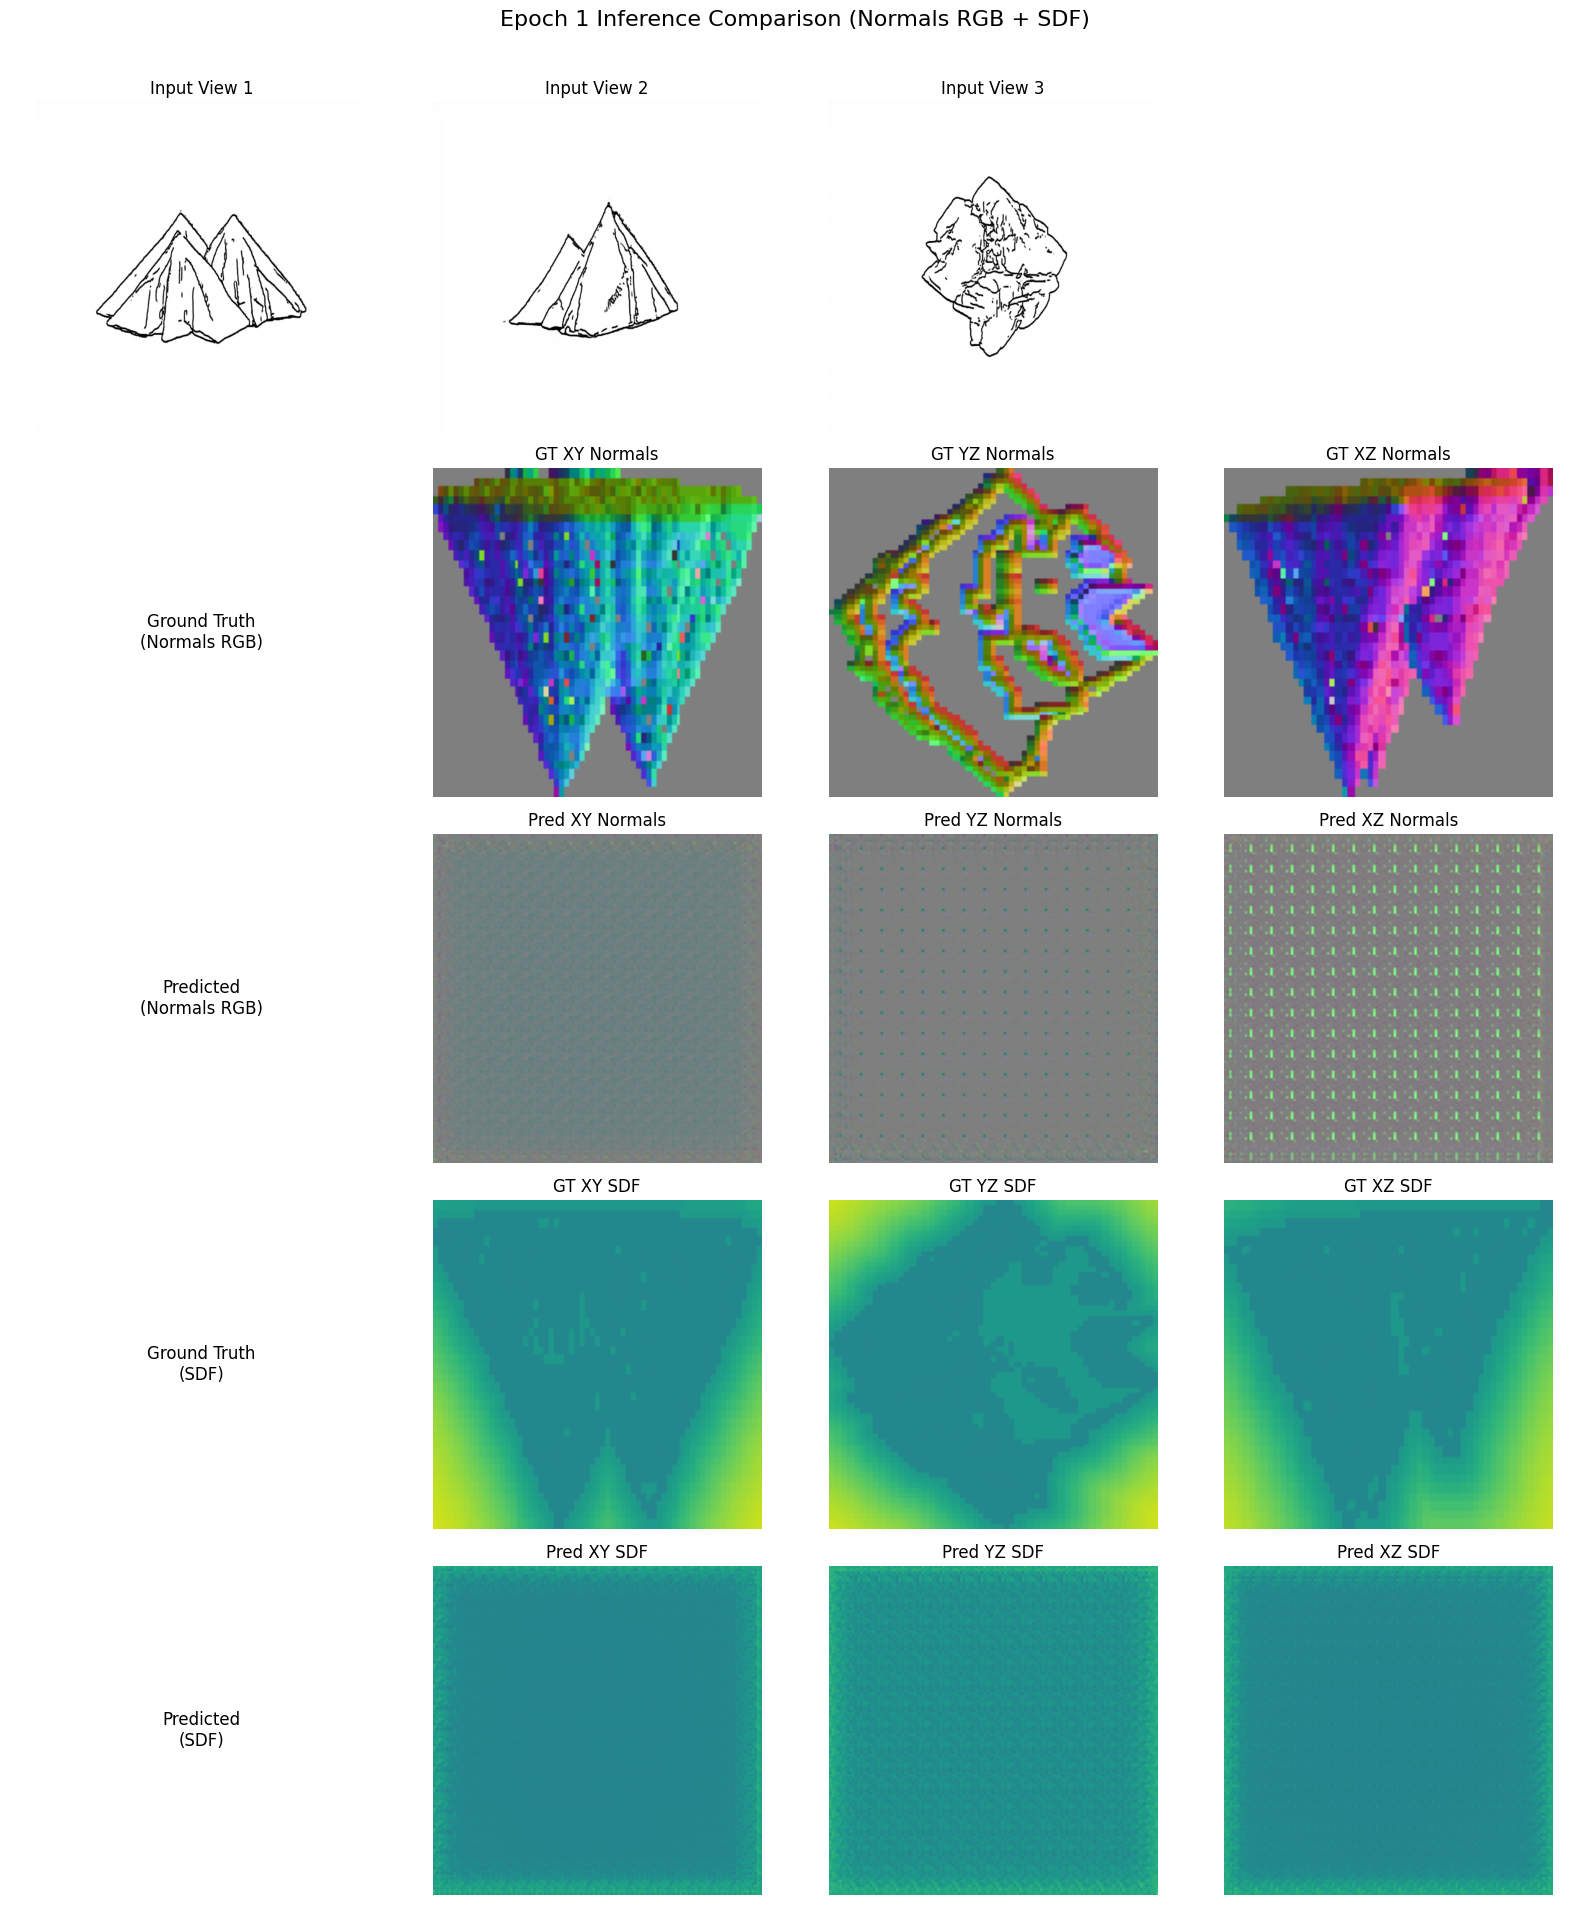


Epoch 2/100


Training:  38%|███▊      | 38/100 [02:56<04:07,  3.99s/it, loss=0.2573, lr=5.00e-05]<ipython-input-4-80f30cb6aa30>:327: RuntimeWarning: divide by zero encountered in scalar divide
  mesh.apply_scale(1.0 / max(mesh.extents))
/usr/local/lib/python3.11/dist-packages/trimesh/transformations.py:2279: RuntimeWarning: invalid value encountered in multiply
  M[:3, :3] *= scale
/usr/local/lib/python3.11/dist-packages/trimesh/voxel/creation.py:48: RuntimeWarning: invalid value encountered in cast
  hit = np.round(v / pitch).astype(int)


Epoch [2/100] Summary | Train Loss: 0.25474 | LR: 0.000050 | Time: 469.41s
Running Validation...


Validation Loss: 0.25885
WandB run was initialized, logging results with wandb.log()
Running epoch-end inference and comparison...
Generated triplane shape: torch.Size([1, 12, 128, 128])
YZ Pred Normal Stats (Nx, Ny, Nz):
  Nx (Ch 8): min=-0.150, max=0.185, mean=-0.003
  Ny (Ch 9): min=-0.139, max=0.141, mean=0.000
  Nz (Ch 10): min=-0.141, max=0.097, mean=0.004
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 0
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 2
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 1
DEBUG: Full test_gt_triplane shape before slicing: (3, 4, 128, 128)
DEBUG: prepare_gt_plane input shape: (1, 4, 128, 128)
DEBUG: prepare_gt_plane input shape: (1, 4, 128, 128)
DEBUG: prepare_gt_plane 

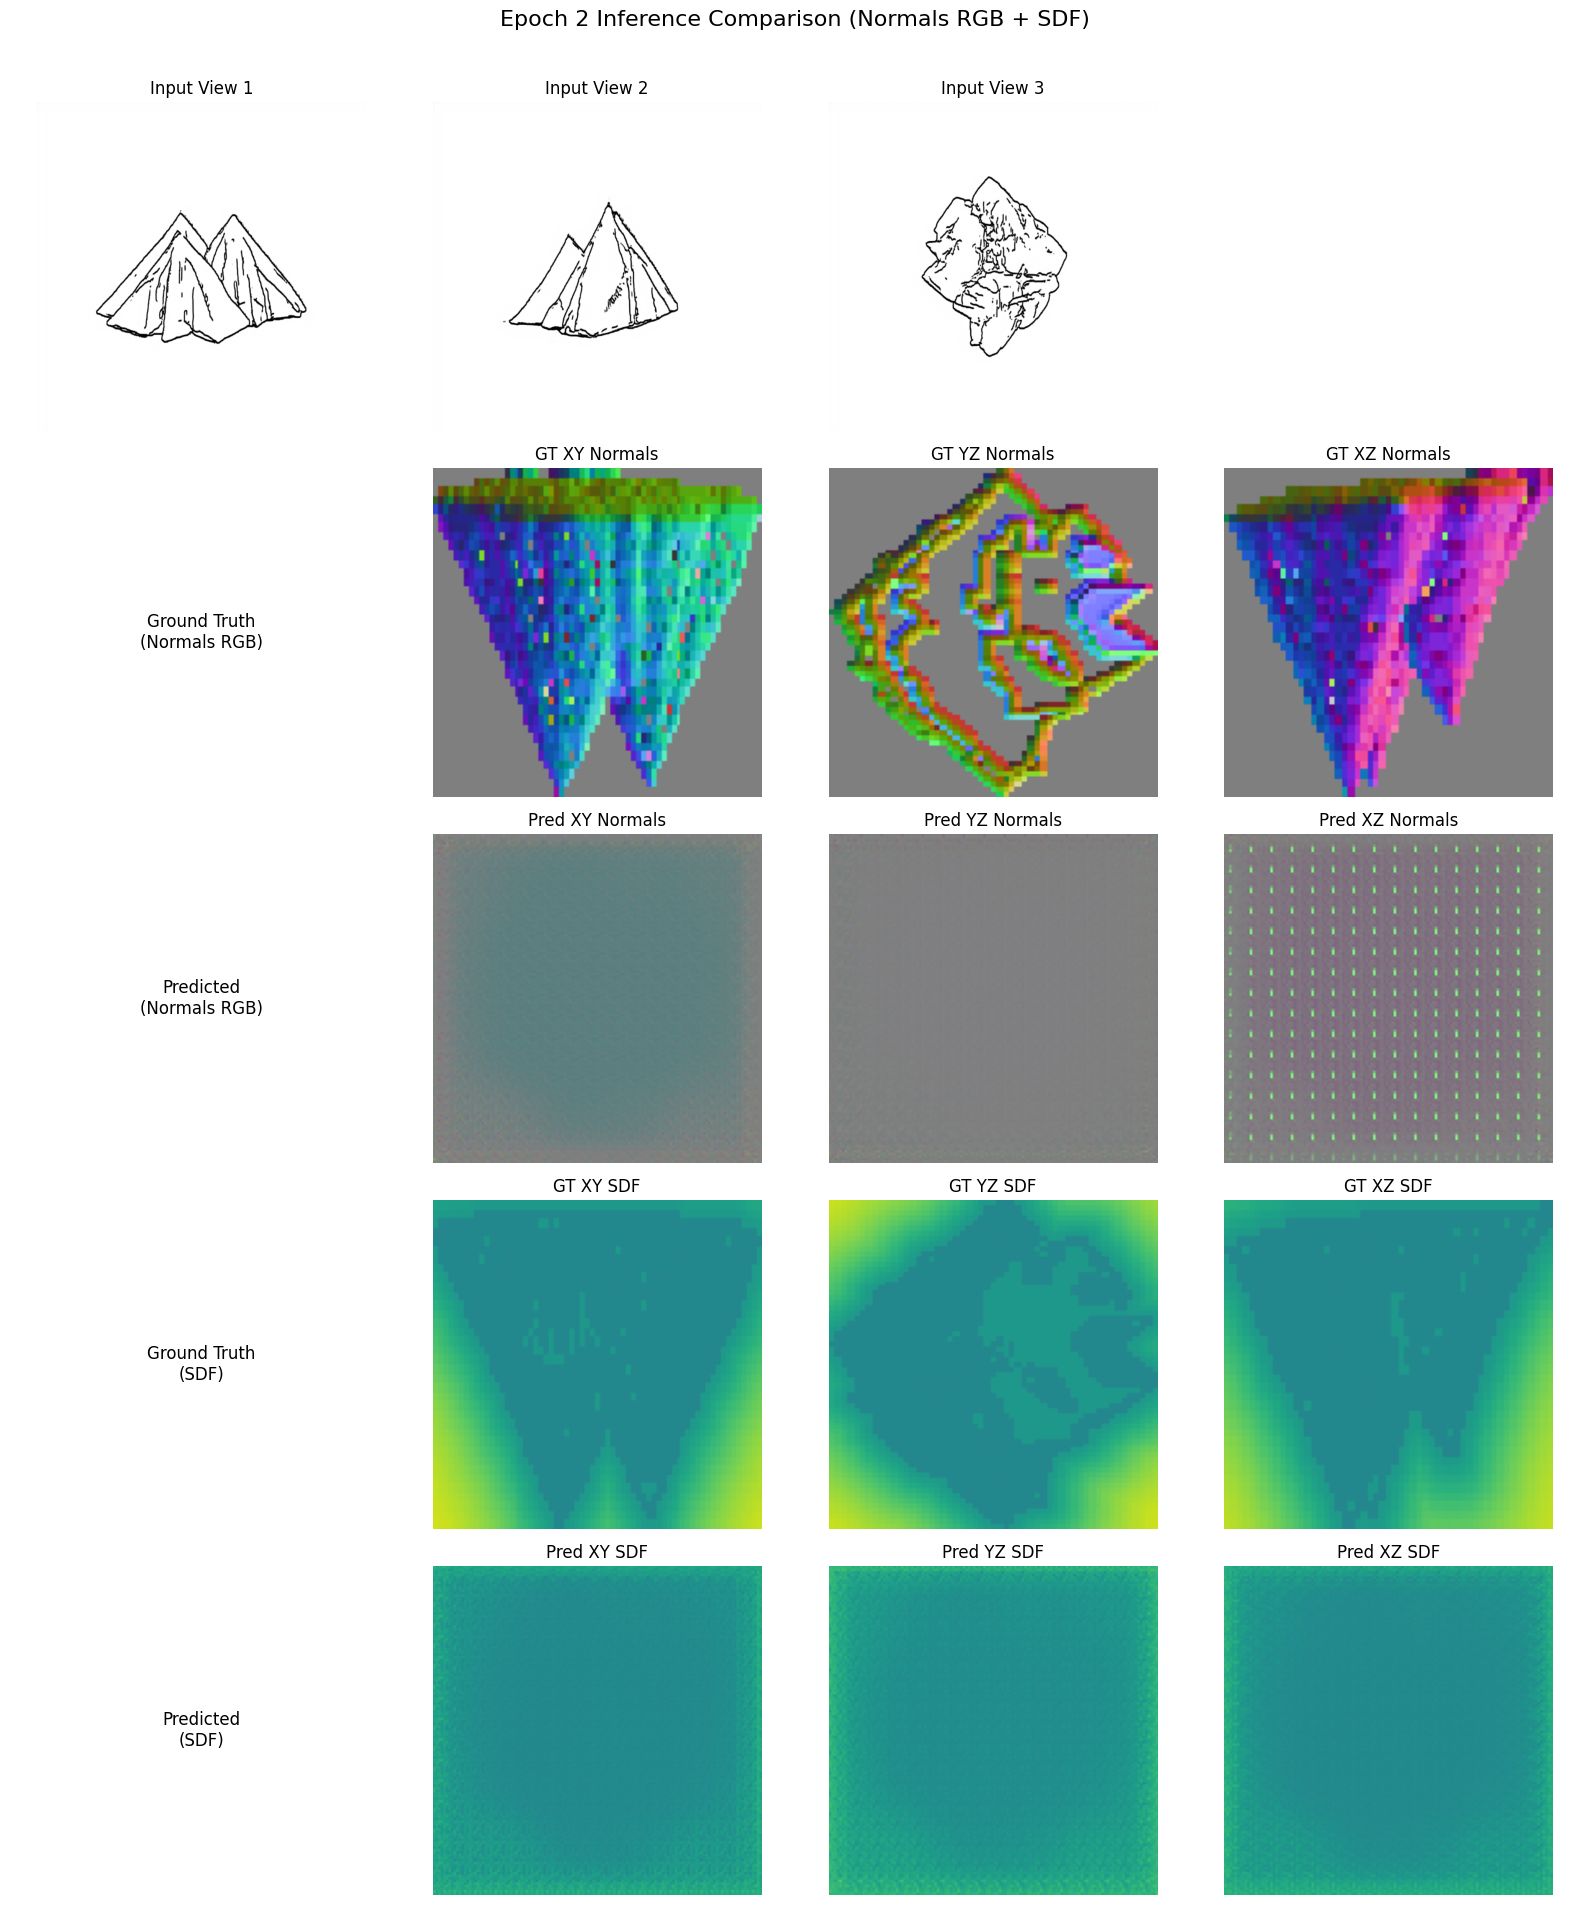


Epoch 3/100


Training:  34%|███▍      | 34/100 [02:43<04:20,  3.95s/it, loss=0.2352, lr=5.00e-05]<ipython-input-4-80f30cb6aa30>:327: RuntimeWarning: divide by zero encountered in scalar divide
  mesh.apply_scale(1.0 / max(mesh.extents))
/usr/local/lib/python3.11/dist-packages/trimesh/transformations.py:2279: RuntimeWarning: invalid value encountered in multiply
  M[:3, :3] *= scale
/usr/local/lib/python3.11/dist-packages/trimesh/voxel/creation.py:48: RuntimeWarning: invalid value encountered in cast
  hit = np.round(v / pitch).astype(int)


Epoch [3/100] Summary | Train Loss: 0.24866 | LR: 0.000050 | Time: 470.16s
Running Validation...


Validation Loss: 0.25386
WandB run was initialized, logging results with wandb.log()
Running epoch-end inference and comparison...
Generated triplane shape: torch.Size([1, 12, 128, 128])
YZ Pred Normal Stats (Nx, Ny, Nz):
  Nx (Ch 8): min=-0.099, max=0.132, mean=-0.003
  Ny (Ch 9): min=-0.105, max=0.145, mean=-0.002
  Nz (Ch 10): min=-0.124, max=0.079, mean=-0.011
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 0
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 2
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 1
DEBUG: Full test_gt_triplane shape before slicing: (3, 4, 128, 128)
DEBUG: prepare_gt_plane input shape: (1, 4, 128, 128)
DEBUG: prepare_gt_plane input shape: (1, 4, 128, 128)
DEBUG: prepare_gt_plan

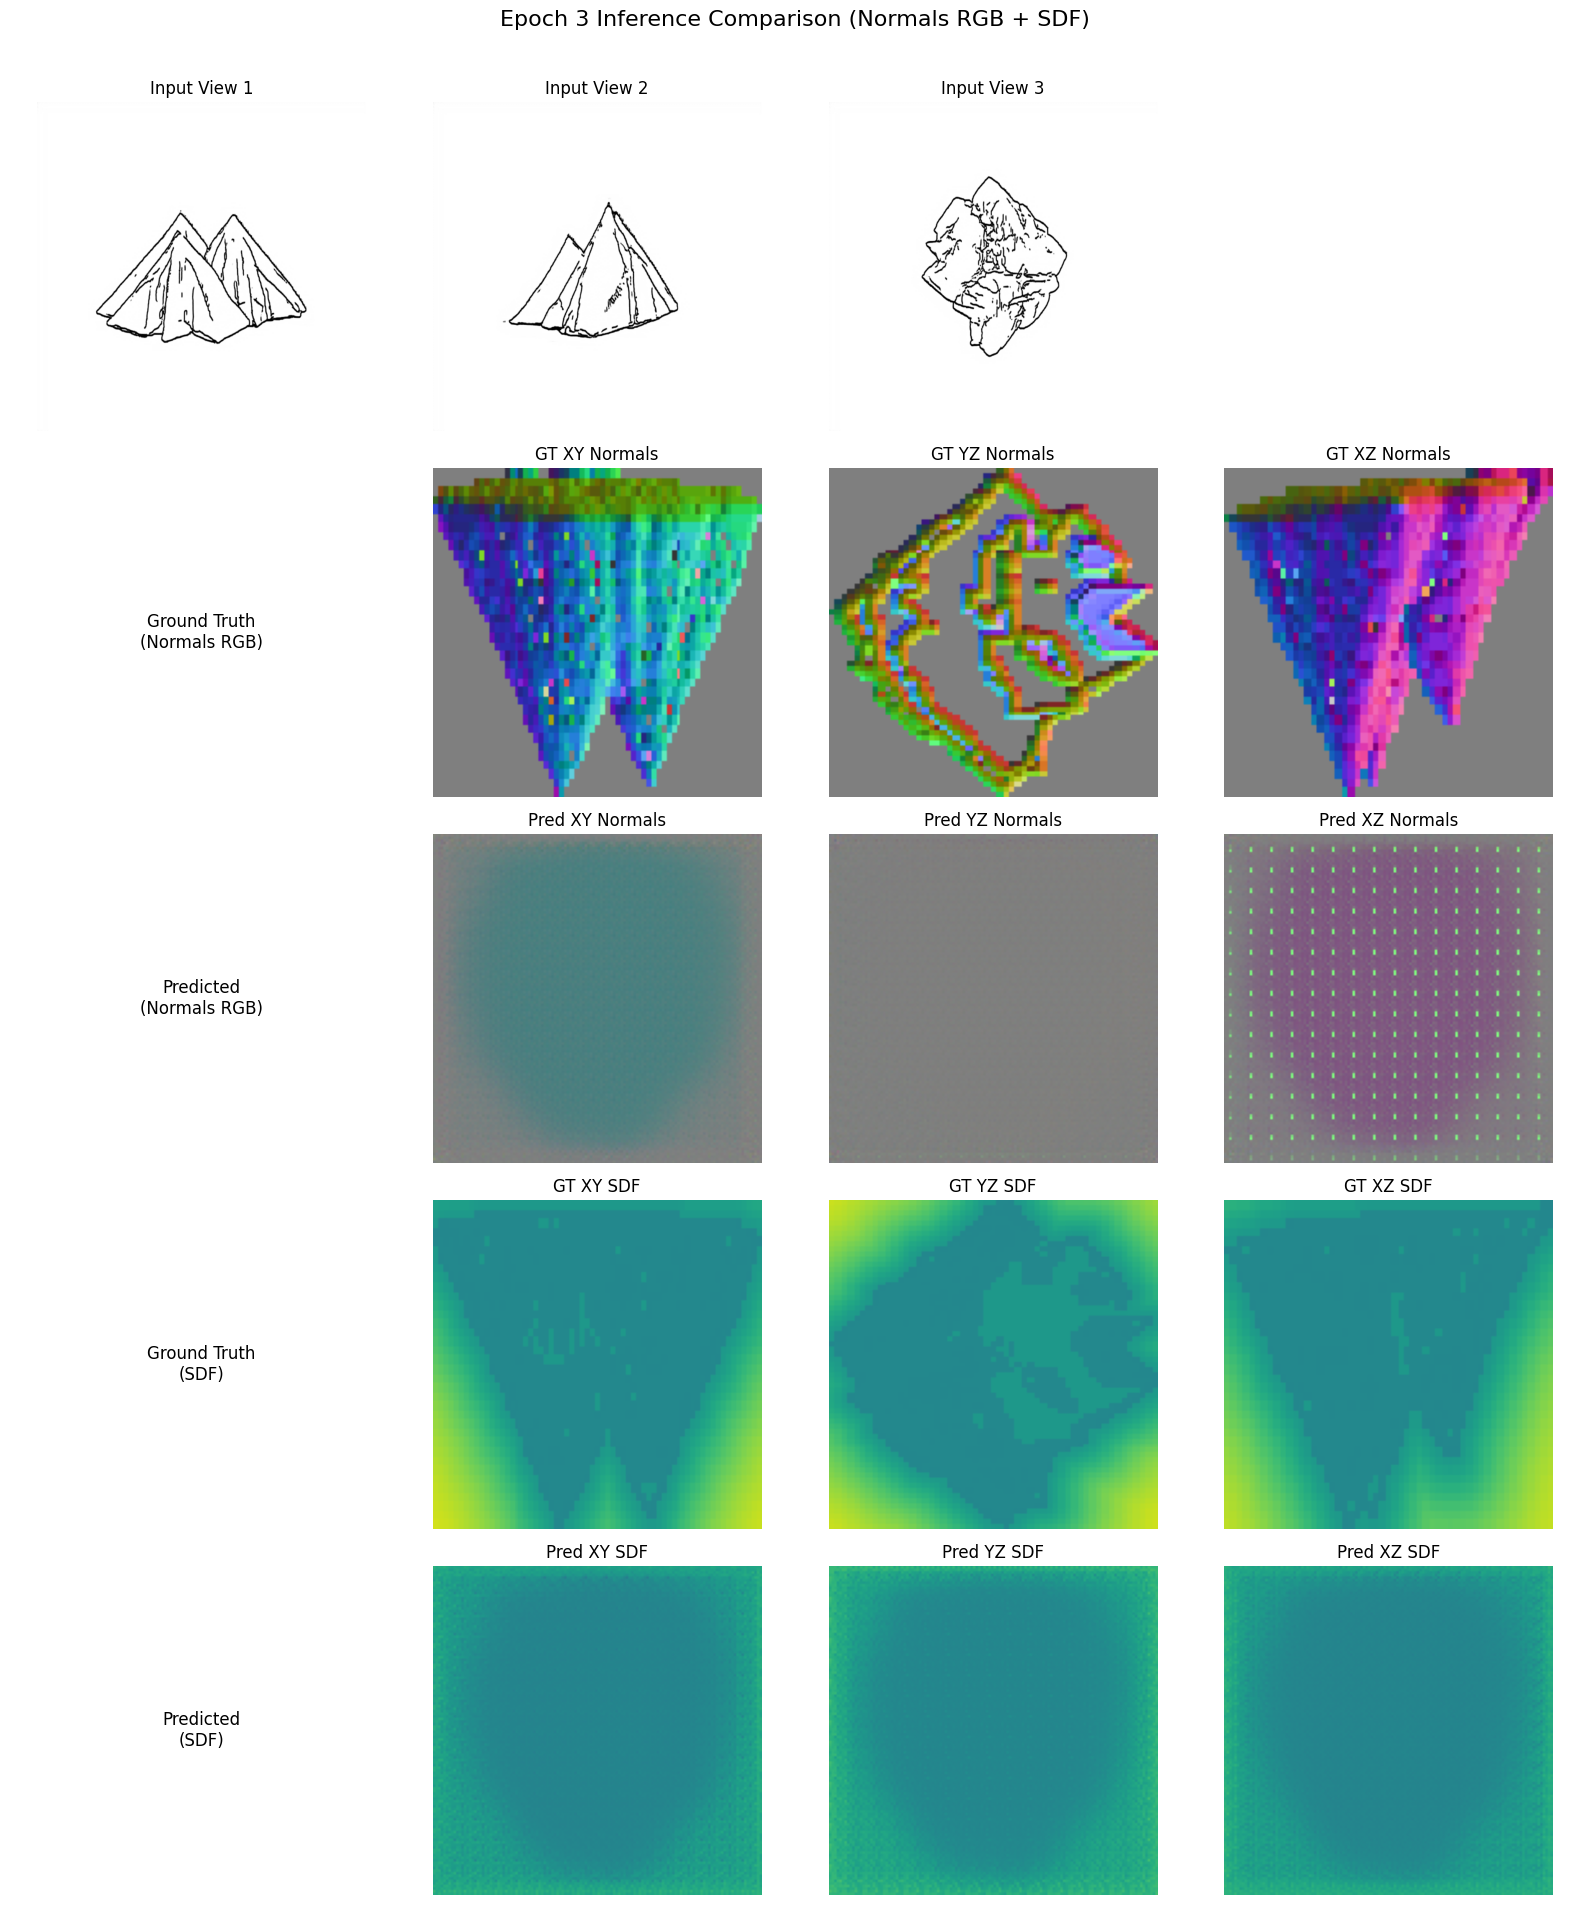


Epoch 4/100


Training:  78%|███████▊  | 78/100 [06:13<01:33,  4.24s/it, loss=0.2592, lr=5.00e-05]<ipython-input-4-80f30cb6aa30>:327: RuntimeWarning: divide by zero encountered in scalar divide
  mesh.apply_scale(1.0 / max(mesh.extents))
/usr/local/lib/python3.11/dist-packages/trimesh/transformations.py:2279: RuntimeWarning: invalid value encountered in multiply
  M[:3, :3] *= scale
/usr/local/lib/python3.11/dist-packages/trimesh/voxel/creation.py:48: RuntimeWarning: invalid value encountered in cast
  hit = np.round(v / pitch).astype(int)


Epoch [4/100] Summary | Train Loss: 0.24442 | LR: 0.000050 | Time: 478.05s
Running Validation...


Validation Loss: 0.25141
WandB run was initialized, logging results with wandb.log()
Running epoch-end inference and comparison...
Generated triplane shape: torch.Size([1, 12, 128, 128])
YZ Pred Normal Stats (Nx, Ny, Nz):
  Nx (Ch 8): min=-0.101, max=0.106, mean=0.001
  Ny (Ch 9): min=-0.087, max=0.150, mean=-0.002
  Nz (Ch 10): min=-0.103, max=0.080, mean=-0.006
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_plane input shape: torch.Size([3, 128, 128])
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 0
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 2
DEBUG: prepare_pred_sdf input shape: torch.Size([12, 128, 128]), plane_index: 1
DEBUG: Full test_gt_triplane shape before slicing: (3, 4, 128, 128)
DEBUG: prepare_gt_plane input shape: (1, 4, 128, 128)
DEBUG: prepare_gt_plane input shape: (1, 4, 128, 128)
DEBUG: prepare_gt_plane

Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/queues.py", line 239, in _feed
    reader_close()
  File "/usr/lib/python3.11/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.11/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


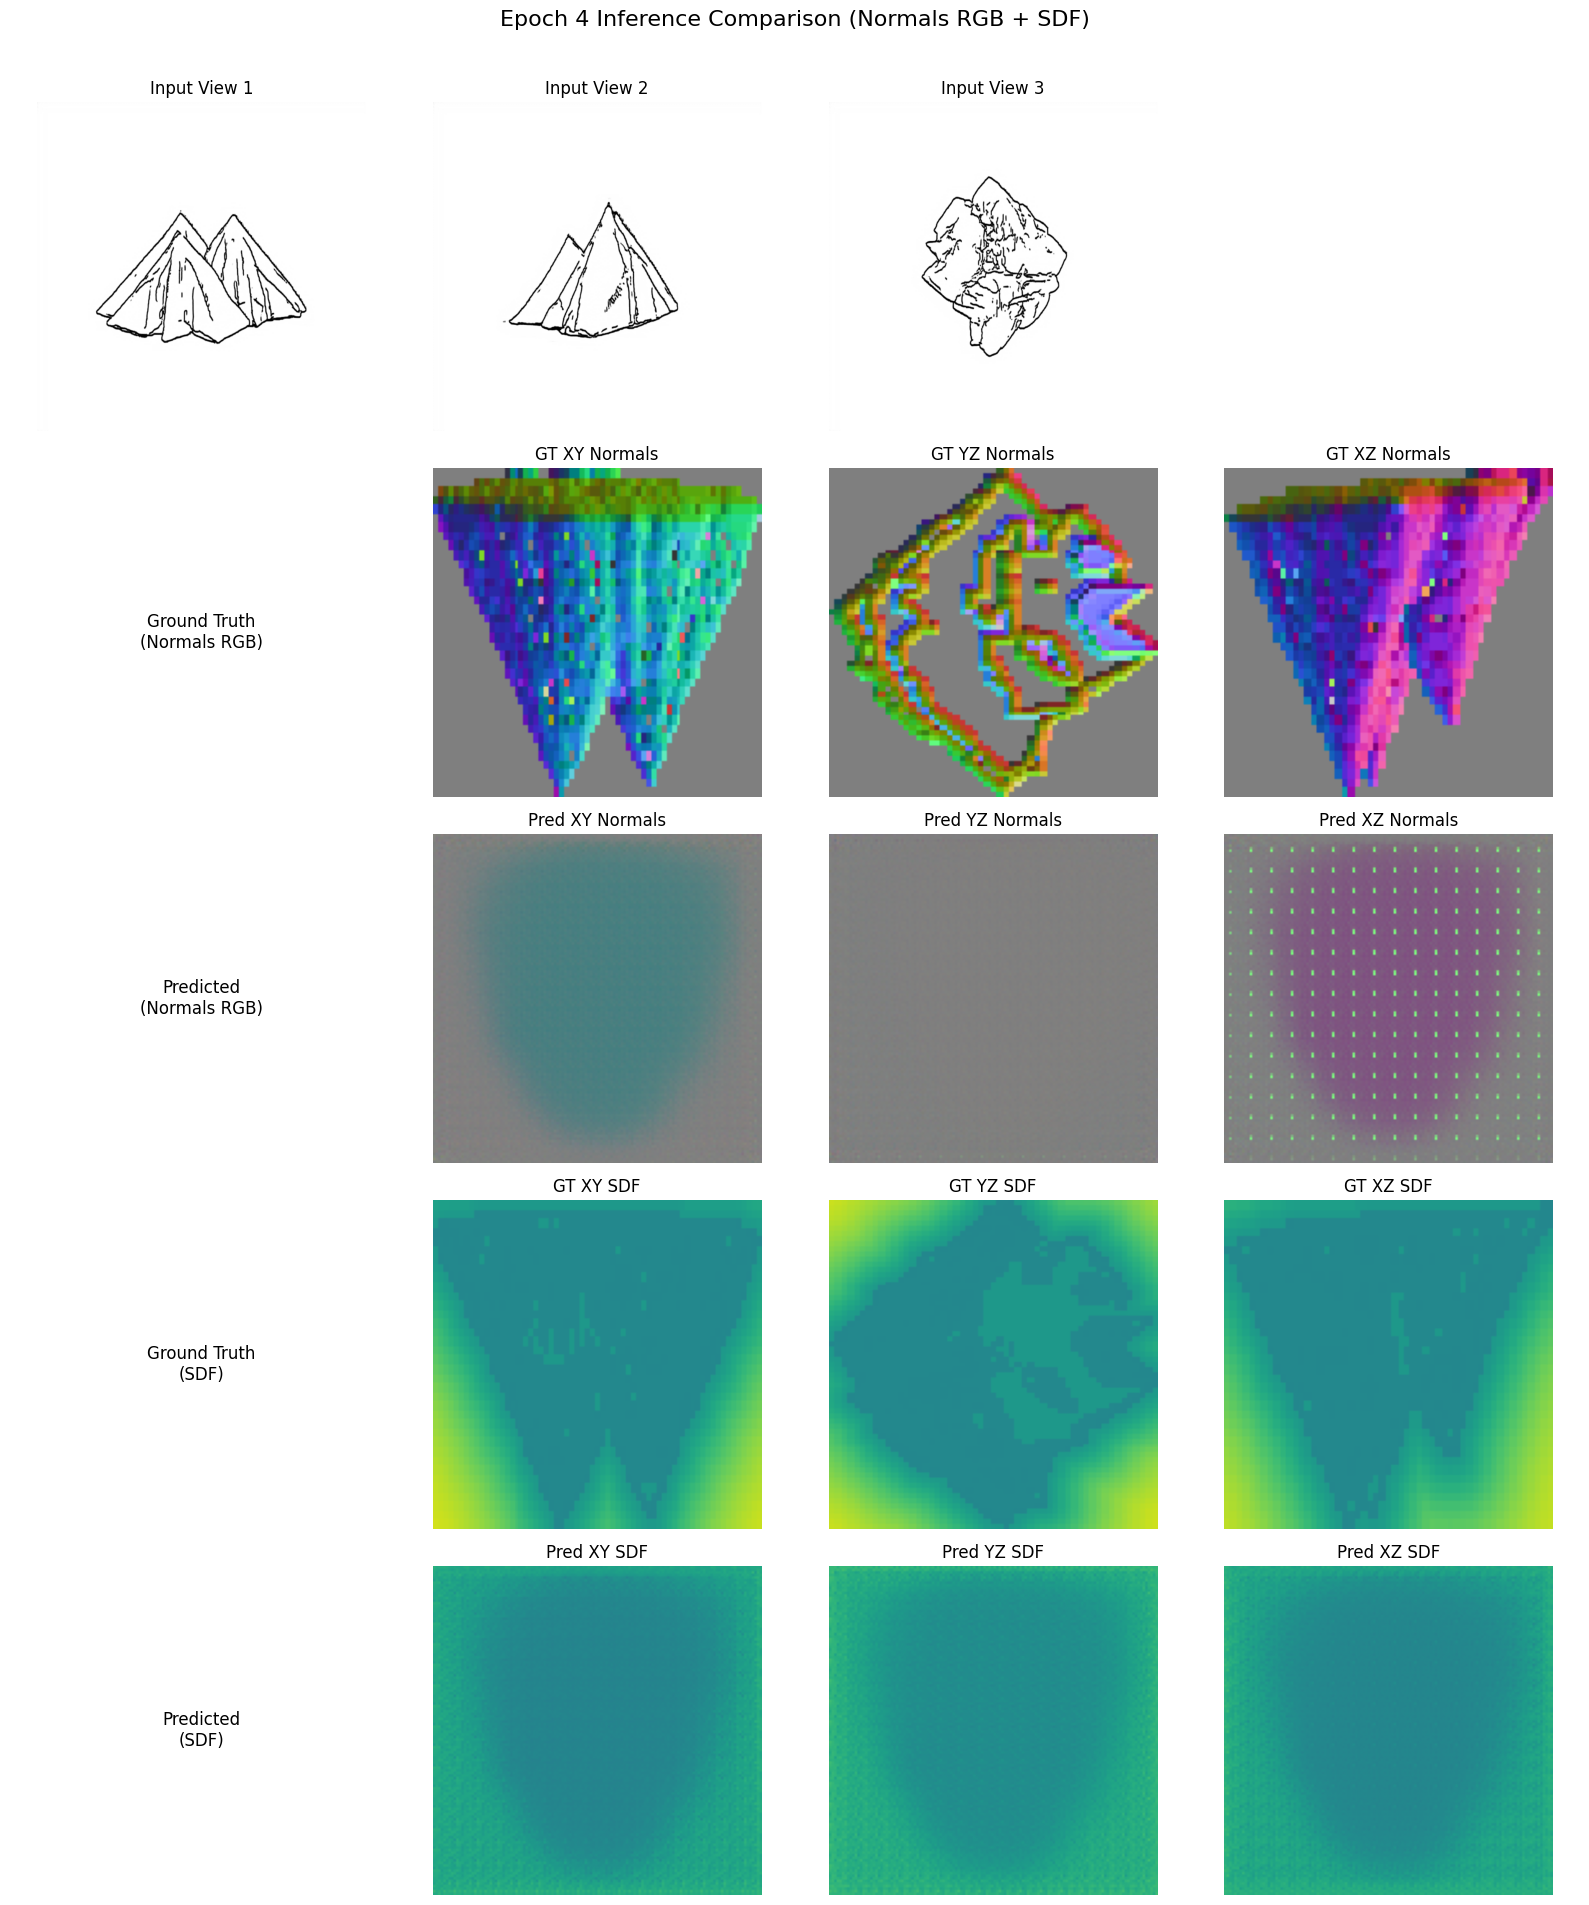


Epoch 5/100


KeyboardInterrupt: 

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from PIL import Image
import numpy as np
import os
import glob
from tqdm import tqdm
import time
import trimesh
import torchvision.transforms.functional as TF
import math
import matplotlib.pyplot as plt # Import for plotting
from torch.utils.data.dataloader import default_collate # Import default_collate
from scipy import ndimage

try:
    from transformers import AutoImageProcessor, AutoModel
except ImportError:
    print("Please install transformers: pip install transformers")
    class DummyAutoImageProcessor:
        @staticmethod
        def from_pretrained(name): print(f"Warning: transformers not found. Using dummy processor for {name}."); return lambda images, return_tensors: {'pixel_values': torch.randn(1, 3, 224, 224)}
    class DummyAutoModel:
        @staticmethod
        def from_pretrained(name): print(f"Warning: transformers not found. Using dummy encoder for {name}."); return nn.Identity() # Modify dummy for testing
        def __call__(self, pixel_values): # Make dummy callable
             # Simulate output structure similar to AutoModel
             batch_size = pixel_values.shape[0]
             seq_len = 16*16 + 1 # Example patch grid + CLS token
             hidden_size = 768  # Example hidden size
             class DummyOutput: # Mimic Hugging Face output structure
                 def __init__(self, last_hidden_state):
                     self.last_hidden_state = last_hidden_state
             return DummyOutput(last_hidden_state=torch.randn(batch_size, seq_len, hidden_size))

    AutoImageProcessor = DummyAutoImageProcessor
    AutoModel = DummyAutoModel

# def mesh_to_triplane_voxel(mesh_path, output_resolution=256, voxel_resolution=128, normalize=True):
#     try:
#         if not os.path.exists(mesh_path):
#              return None
#         mesh = trimesh.load(mesh_path, force='mesh', process=False)
#         if isinstance(mesh, trimesh.Scene): mesh = mesh.dump(concatenate=True)
#         if not isinstance(mesh, trimesh.Trimesh):
#              return None
#         if len(mesh.vertices) == 0 or len(mesh.faces) == 0:
#             return None
#         try:
#             unique_faces = mesh.unique_faces(); mesh.update_faces(unique_faces)
#             mesh.remove_unreferenced_vertices()
#         except Exception as proc_e: print(f"Warning: Mesh proc error {mesh_path}: {proc_e}.")
#         if normalize:
#             try:
#                 center = mesh.bounds.mean(axis=0); mesh.apply_translation(-center)
#                 max_extent = np.ptp(mesh.bounds, axis=0).max()
#                 if max_extent > 1e-6: mesh.apply_scale(1.0 / max_extent)
#             except Exception as norm_e: print(f"Warning: Normalize error {mesh_path}: {norm_e}")
#         try:
#             pitch = 1.0 / voxel_resolution
#             voxel_grid = mesh.voxelized(pitch=pitch)
#             voxel_matrix = voxel_grid.matrix.astype(np.float32)
#             current_shape = voxel_matrix.shape
#             target_shape = (voxel_resolution, voxel_resolution, voxel_resolution)
#             padded_matrix = np.zeros(target_shape, dtype=np.float32)
#             min_shape = tuple(min(s, t) for s, t in zip(current_shape, target_shape))
#             padded_matrix[:min_shape[0], :min_shape[1], :min_shape[2]] = \
#                 voxel_matrix[:min_shape[0], :min_shape[1], :min_shape[2]]
#             voxel_matrix = padded_matrix
#         except Exception as vox_e: print(f"Error voxelizing {mesh_path}: {vox_e}"); return None
#         if voxel_matrix.sum() == 0:
#             return None

#         plane_xy = np.max(voxel_matrix, axis=2)
#         plane_yz = np.max(voxel_matrix, axis=0)
#         plane_xz = np.max(voxel_matrix, axis=1)

#         plane_xy_t = torch.from_numpy(plane_xy).unsqueeze(0).float()
#         plane_yz_t = torch.from_numpy(plane_yz).unsqueeze(0).float()
#         plane_xz_t = torch.from_numpy(plane_xz).unsqueeze(0).float()

#         target_size = (output_resolution, output_resolution)
#         plane_xy_t = F.interpolate(plane_xy_t.unsqueeze(0), size=target_size, mode='bilinear', align_corners=False).squeeze(0)
#         plane_yz_t = F.interpolate(plane_yz_t.unsqueeze(0), size=target_size, mode='bilinear', align_corners=False).squeeze(0)
#         plane_xz_t = F.interpolate(plane_xz_t.unsqueeze(0), size=target_size, mode='bilinear', align_corners=False).squeeze(0)

#         plane_xy_rgb = plane_xy_t.repeat(3, 1, 1)
#         plane_yz_rgb = plane_yz_t.repeat(3, 1, 1)
#         plane_xz_rgb = plane_xz_t.repeat(3, 1, 1)

#         triplane_tensor = torch.cat([plane_xy_rgb, plane_yz_rgb, plane_xz_rgb], dim=0)
#         triplane_tensor = torch.clamp(triplane_tensor, 0.0, 1.0)
#         return triplane_tensor
#     except Exception as e:
#         return None

# --- MODIFIED Dataset ---
class ImageMeshToTriplaneDataset(Dataset):
    def __init__(self, image_dir_v1, image_dir_v2, image_dir_v3, mesh_dir, image_processor,
                 triplane_resolution=256, voxel_grid_resolution=128, debug=False): # !!!Debug to train on tiny subset
        self.image_dir_v1 = image_dir_v1
        self.image_dir_v2 = image_dir_v2
        self.image_dir_v3 = image_dir_v3
        self.mesh_dir = mesh_dir
        self.image_processor = image_processor
        self.triplane_resolution = triplane_resolution
        self.voxel_grid_resolution = voxel_grid_resolution
        self.mesh_ext = ".obj"
        self.image_exts = (".jpg", ".png", ".jpeg") # Added jpeg

        # --- Validation for directories ---
        for dir_path in [image_dir_v1, image_dir_v2, image_dir_v3, mesh_dir]:
             if not os.path.isdir(dir_path):
                 raise FileNotFoundError(f"Directory not found: {dir_path}")

        # --- Scan files and find matching base names ---
        print("Scanning image and mesh directories...")
        image_map_v1 = self._scan_dir(image_dir_v1)
        image_map_v2 = self._scan_dir(image_dir_v2)
        image_map_v3 = self._scan_dir(image_dir_v3)
        mesh_map = self._scan_dir(mesh_dir, self.mesh_ext)
        print(f"Found {len(image_map_v1)} unique image base names in {image_dir_v1}")
        print(f"Found {len(image_map_v2)} unique image base names in {image_dir_v2}")
        print(f"Found {len(image_map_v3)} unique image base names in {image_dir_v3}")
        print(f"Found {len(mesh_map)} unique mesh base names in {mesh_dir}")

        # Find common base names across all four sources
        common_bases = set(image_map_v1.keys()) & set(image_map_v2.keys()) & set(image_map_v3.keys()) & set(mesh_map.keys())
        self.valid_files = sorted(list(common_bases))

        # --- DEBUG ---
        if debug:
          subset_size = 25
          if len(self.valid_files) > subset_size:
              print(f"Using subset of {subset_size} files for debugging.")
              self.valid_files = self.valid_files[:subset_size]
          print(f"Valid files: {self.valid_files}")
        # --- DEBUG ---


        # Create path maps only for valid files
        self.image_path_map_v1 = {base: image_map_v1[base] for base in self.valid_files}
        self.image_path_map_v2 = {base: image_map_v2[base] for base in self.valid_files}
        self.image_path_map_v3 = {base: image_map_v3[base] for base in self.valid_files}
        self.mesh_path_map = {base: mesh_map[base] for base in self.valid_files}

        print(f"Found {len(self.valid_files)} matching sets (image_v1/image_v2/image_v3/mesh).")
        if not self.valid_files:
            print(f"Warning: No matching file sets found! Check base names and extensions.")
            print(f" - Image Dirs: {image_dir_v1}, {image_dir_v2}, {image_dir_v3}")
            print(f" - Mesh Dir: {mesh_dir}")
            print(f" - Image Exts: {self.image_exts}")
            print(f" - Mesh Ext: {self.mesh_ext}")


    def _scan_dir(self, dir_path, extensions=None):
        """Helper function to scan a directory and map base names to full paths."""
        if extensions is None:
            extensions = self.image_exts
        if isinstance(extensions, str):
            extensions = (extensions,) # Ensure it's a tuple

        file_map = {}
        print(f"Scanning {dir_path} for {extensions} files...")
        for ext in extensions:
            pattern = os.path.join(dir_path, f"*{ext}")
            # Use case-insensitive matching on Windows if needed (glob is usually case-sensitive on Linux)
            # On Windows, glob might already be case-insensitive, but explicit check can be added
            found_files = glob.glob(pattern)
            for p in found_files:
                base = os.path.splitext(os.path.basename(p))[0]
                # Handle potential duplicates if extensions overlap (.jpeg vs .jpg) - keep first found
                if base not in file_map:
                     file_map[base] = p
        return file_map

    def __len__(self):
        return len(self.valid_files)

    def __getitem__(self, idx):
        if idx >= len(self.valid_files):
            raise IndexError("Index out of bounds")

        base_name = self.valid_files[idx]
        img_path_v1 = self.image_path_map_v1.get(base_name)
        img_path_v2 = self.image_path_map_v2.get(base_name)
        img_path_v3 = self.image_path_map_v3.get(base_name)
        mesh_path = self.mesh_path_map.get(base_name)

        if not all([img_path_v1, img_path_v2, img_path_v3, mesh_path]):
            # This should ideally not happen if valid_files is constructed correctly, but as a safeguard:
            print(f"Error: Path mapping missing for base name '{base_name}' at index {idx}. Skipping.")
             # Return None to be filtered by collate_fn
            return None # Or raise an error

        try:
            # Load and process images
            image_v1 = Image.open(img_path_v1).convert("RGB")
            image_v2 = Image.open(img_path_v2).convert("RGB")
            image_v3 = Image.open(img_path_v3).convert("RGB")

            processed_image_v1 = self.image_processor(images=image_v1, return_tensors="pt")['pixel_values'].squeeze(0)
            processed_image_v2 = self.image_processor(images=image_v2, return_tensors="pt")['pixel_values'].squeeze(0)
            processed_image_v3 = self.image_processor(images=image_v3, return_tensors="pt")['pixel_values'].squeeze(0)

            # Generate triplane tensor
            # triplane_tensor = mesh_to_triplane_voxel(
            #     mesh_path,
            #     output_resolution=self.triplane_resolution,
            #     voxel_resolution=self.voxel_grid_resolution
            # )

            # Create the advanced triplane

            ##################################################################################
            voxel_matrix = convert_to_voxel(mesh_path)
            ##################################################################################
            triplane_tensor = mesh_to_advanced_triplane(voxel_matrix, self.triplane_resolution)
            ##################################################################################

            # triplane_tensor = mesh_to_triplane_voxel(
            #     mesh_path,
            #     output_resolution=self.triplane_resolution,
            #     voxel_resolution=self.voxel_grid_resolution
            # )

            if triplane_tensor is None:
                # mesh_to_triplane_voxel now prints warnings, so just log skipping
                print(f"Warning: Failed voxel triplane generation for {base_name} ({mesh_path}). Skipping item.")
                return None # Signal to collate_fn to skip

            # Return tuple of images and the triplane
            return (processed_image_v1, processed_image_v2, processed_image_v3), triplane_tensor

        except FileNotFoundError as fnf_err:
             print(f"Error: File not found during processing item {idx} ('{base_name}'): {fnf_err}. Skipping.")
             return None
        except Exception as e:
            print(f"Error processing item {idx} ('{base_name}'): {e}. Skipping.")
            # Consider logging the full traceback for debugging
            # import traceback
            # traceback.print_exc()
            return None # Signal to collate_fn to skip


class PositionalEncoding2D(nn.Module):
    # --- This class remains the same ---
    def __init__(self, d_model, height, width):
        super().__init__()
        if d_model % 4 != 0:
            raise ValueError("Cannot use sin/cos positional encoding with odd dimension (got dim={:d})".format(d_model))
        pe = torch.zeros(d_model, height, width)
        d_model_h = d_model // 2 # For height dimension
        d_model_w = d_model // 2 # For width dimension (split channels)

        div_term_h = torch.exp(torch.arange(0., d_model_h, 2) * -(math.log(10000.0) / d_model_h))
        pos_h = torch.arange(0., height).unsqueeze(1)
        # Apply positional encoding for height to the first half of the channels
        pe[0:d_model_h:2, :, :] = torch.sin(pos_h * div_term_h).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)
        pe[1:d_model_h:2, :, :] = torch.cos(pos_h * div_term_h).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)

        div_term_w = torch.exp(torch.arange(0., d_model_w, 2) * -(math.log(10000.0) / d_model_w))
        pos_w = torch.arange(0., width).unsqueeze(1)
        # Apply positional encoding for width to the second half of the channels
        pe[d_model_h::2, :, :] = torch.sin(pos_w * div_term_w).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
        pe[d_model_h+1::2, :, :] = torch.cos(pos_w * div_term_w).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)

        self.register_buffer('pe', pe.unsqueeze(0)) # Add batch dimension

    def forward(self, x):
        # x shape: [B, C, H, W]
        # pe shape: [1, C, H, W]
        # Add positional encoding to the input feature map
        x = x + self.pe[:, :, :x.size(2), :x.size(3)]
        return x


# --- MODIFIED Decoder ---
class TriplaneDecoder(nn.Module):
    def __init__(self, encoder_dim=768, decoder_dim=512, decoder_layers=4, decoder_heads=8,
                 output_channels=9, output_resolution=256, input_patch_grid_res=16):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.decoder_dim = decoder_dim # Target dimension after projection/combination
        self.output_resolution = output_resolution
        self.input_patch_grid_res = input_patch_grid_res
        self.num_patches = input_patch_grid_res * input_patch_grid_res

        # Projection layer for *each* encoder output before combination
        self.input_proj = nn.Linear(encoder_dim, decoder_dim)

        # Positional encoding for the combined spatial features
        self.pos_encoder = PositionalEncoding2D(decoder_dim, input_patch_grid_res, input_patch_grid_res)

        # Transformer Decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=decoder_dim, nhead=decoder_heads, dim_feedforward=decoder_dim * 4,
            dropout=0.1, activation=F.relu, batch_first=True, norm_first=True) # Using norm_first
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=decoder_layers)

        # Upsampling Neck
        num_upsample_stages = int(math.log2(output_resolution // input_patch_grid_res))
        if input_patch_grid_res * (2**num_upsample_stages) != output_resolution:
            raise ValueError("Output resolution must be a power-of-2 multiple of input_patch_grid_res")

        upsample_layers = []
        current_dim = decoder_dim
        for i in range(num_upsample_stages):
            out_dim = max(decoder_dim // (2**(i+1)), output_channels * 2) # Ensure final dim isn't too small
            upsample_layers.append(nn.Sequential(
                nn.ConvTranspose2d(current_dim, out_dim, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True),
                # Added another Conv layer per stage for more capacity
                nn.Conv2d(out_dim, out_dim, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True)
            ))
            # upsample_layers.append(nn.Sequential(
            #     nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False), # Bilinear Upsample # <-- this is experimental and might not fit dimensions
            #     nn.Conv2d(current_dim, out_dim, kernel_size=3, padding=1), # Conv after upsample
            #     nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True),
            #     nn.Conv2d(out_dim, out_dim, kernel_size=3, padding=1), # Keep second conv
            #     nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True)
            # ))
            current_dim = out_dim
        self.upsample_neck = nn.Sequential(*upsample_layers)

        # Final Output Projection
        self.output_proj = nn.Conv2d(current_dim, output_channels, kernel_size=1, stride=1, padding=0) # Use 1x1 conv
        self.output_activation = nn.Tanh() # Tanh activation [-1, 1]

    def forward(self, patch_embeddings_v1, patch_embeddings_v2, patch_embeddings_v3):
        # Input shapes: [B, N+1 or N, encoder_dim]

        # --- 1. Handle CLS token and Project each view ---
        projected_embeddings = []
        for pe in [patch_embeddings_v1, patch_embeddings_v2, patch_embeddings_v3]:
            # Remove CLS token if present (assume it's the first token)
            if pe.shape[1] == self.num_patches + 1:
                pe_no_cls = pe[:, 1:, :] # Shape: [B, N, encoder_dim]
            elif pe.shape[1] == self.num_patches:
                pe_no_cls = pe # Shape: [B, N, encoder_dim]
            else:
                raise ValueError(f"Input sequence length ({pe.shape[1]}) does not match expected num_patches ({self.num_patches}) or num_patches+1.")
            # Project to decoder dimension
            projected = self.input_proj(pe_no_cls) # Shape: [B, N, decoder_dim]
            projected_embeddings.append(projected)

        # --- 2. Combine Features (Addition) ---
        # Add the projected embeddings element-wise
        combined_embeddings = projected_embeddings[0] + projected_embeddings[1] + projected_embeddings[2]
        # combined_embeddings shape: [B, N, decoder_dim]
        batch_size = combined_embeddings.shape[0]

        # --- 3. Reshape and Add Positional Encoding ---
        # Reshape sequence to spatial grid: [B, N, C] -> [B, C, H, W]
        spatial_input = combined_embeddings.permute(0, 2, 1).reshape(
            batch_size, self.decoder_dim, self.input_patch_grid_res, self.input_patch_grid_res)
        spatial_input_with_pos = self.pos_encoder(spatial_input)

        # --- 4. Transformer Decoder ---
        # Reshape back to sequence for transformer: [B, C, H, W] -> [B, N, C]
        seq_with_pos = spatial_input_with_pos.flatten(2).permute(0, 2, 1)
        # Transformer decoder acts like a self-attention refinement here
        # We use the same sequence for `tgt` and `memory` as common in generative tasks
        refined_seq = self.transformer_decoder(tgt=seq_with_pos, memory=seq_with_pos)
        # refined_seq shape: [B, N, decoder_dim]

        # --- 5. Reshape and Upsample ---
        # Reshape transformer output back to spatial grid: [B, N, C] -> [B, C, H, W]
        spatial_features = refined_seq.permute(0, 2, 1).reshape(
            batch_size, self.decoder_dim, self.input_patch_grid_res, self.input_patch_grid_res)
        upsampled_features = self.upsample_neck(spatial_features)
        # upsampled_features shape: [B, final_neck_dim, output_res, output_res]

        # --- 6. Final Projection and Activation ---
        output_logits = self.output_proj(upsampled_features) # Shape: [B, output_channels, output_res, output_res]
        output_triplane = self.output_activation(output_logits) # Shape: [B, 9, 256, 256]

        return output_triplane

# --- MODIFIED Model ---
class ViTTriplaneGenerator(nn.Module):
    def __init__(self, encoder_model_name="facebook/dinov2-base", decoder_dim=512, decoder_layers=4,
                 decoder_heads=8, output_channels=9, output_resolution=256, input_patch_grid_res=16,
                 freeze_encoder=True):
        super().__init__()
        self.encoder_model_name = encoder_model_name
        self.output_resolution = output_resolution
        self.output_channels = output_channels

        print(f"Loading encoder: {encoder_model_name}...")
        self.encoder = AutoModel.from_pretrained(encoder_model_name)
        try:
            # Attempt to get hidden size correctly
            if hasattr(self.encoder, 'config') and hasattr(self.encoder.config, 'hidden_size'):
                 encoder_output_dim = self.encoder.config.hidden_size
            elif isinstance(self.encoder, nn.Identity): # Handle dummy case explicitly
                 print("Using Dummy Encoder: Assuming encoder_output_dim 768.")
                 encoder_output_dim = 768
            else:
                 # Fallback if config structure is unexpected
                 print("Warning: Could not automatically determine encoder hidden_size. Assuming 768.")
                 encoder_output_dim = 768 # Default assumption
        except Exception as e:
             print(f"Warning: Error determining encoder dimension ({e}). Assuming 768.")
             encoder_output_dim = 768

        print(f"Encoder loaded. Output dimension assumed: {encoder_output_dim}")

        self.decoder = TriplaneDecoder(
            encoder_dim=encoder_output_dim, decoder_dim=decoder_dim, decoder_layers=decoder_layers,
            decoder_heads=decoder_heads, output_channels=output_channels, output_resolution=output_resolution,
            input_patch_grid_res=input_patch_grid_res)

        if freeze_encoder:
            self.freeze_encoder()
        else:
            self.unfreeze_encoder() # Explicitly unfreeze if freeze_encoder is False

    def freeze_encoder(self):
        print("Freezing encoder weights.")
        if hasattr(self, 'encoder') and isinstance(self.encoder, nn.Module): # Check if encoder exists and is a Module
            for param in self.encoder.parameters():
                param.requires_grad = False
            self.encoder.eval() # Set encoder to evaluation mode when frozen
        else:
             print("Warning: Encoder not found or not an nn.Module, cannot freeze.")


    def unfreeze_encoder(self):
        print("Unfreezing encoder weights.")
        if hasattr(self, 'encoder') and isinstance(self.encoder, nn.Module):
            for param in self.encoder.parameters():
                param.requires_grad = True
            self.encoder.train() # Set encoder back to training mode if unfrozen
        else:
            print("Warning: Encoder not found or not an nn.Module, cannot unfreeze.")

    # Modified forward to accept three inputs
    def forward(self, pixel_values_v1, pixel_values_v2, pixel_values_v3):
        is_encoder_frozen = not any(p.requires_grad for p in self.encoder.parameters()) if hasattr(self, 'encoder') else True

        # Run encoder for each view
        # Use torch.no_grad() context if frozen, else allow gradients
        with torch.set_grad_enabled(not is_encoder_frozen):
            encoder_outputs_v1 = self.encoder(pixel_values=pixel_values_v1)
            encoder_outputs_v2 = self.encoder(pixel_values=pixel_values_v2)
            encoder_outputs_v3 = self.encoder(pixel_values=pixel_values_v3)

        # Extract patch embeddings (last hidden state)
        patch_embeddings_v1 = encoder_outputs_v1.last_hidden_state
        patch_embeddings_v2 = encoder_outputs_v2.last_hidden_state
        patch_embeddings_v3 = encoder_outputs_v3.last_hidden_state

        # Pass all three to the decoder
        generated_triplane = self.decoder(patch_embeddings_v1, patch_embeddings_v2, patch_embeddings_v3)

        # Return only the generated triplane
        return generated_triplane


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

import wandb
import time

# --- MODIFIED Paths ---
# Define paths for the THREE view directories
TRAIN_IMAGE_DIR_V1 = "/content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/front" # CHANGE TO YOUR ACTUAL PATH
TRAIN_IMAGE_DIR_V2 = "/content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/right" # CHANGE TO YOUR ACTUAL PATH
TRAIN_IMAGE_DIR_V3 = "/content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/top" # CHANGE TO YOUR ACTUAL PATH
TRAIN_MESH_DIR = "/content/drive/MyDrive/Image_2D-3D_Source_folder/Dataset/3dmodel"      # CHANGE TO YOUR ACTUAL PATH

ENC_MODEL_NAME = "facebook/dinov2-base"
DEC_DIM = 512           # Decoder internal dimension (512 default)
DEC_LAYERS = 6          # Increased layers
DEC_HEADS = 8
OUT_CH = 12              # 3 channels per plane (XY, YZ, XZ)
OUT_RES = 128           # Triplane image resolution
PATCH_GRID_RES = 16     # ViT patch grid (e.g., 224 / 14 = 16 for ViT-B/14)
VOXEL_RES = 128         # Resolution for intermediate voxel grid

LEARNING_RATE = 5e-5      # Adjusted LR
BATCH_SIZE = 4            # Adjusted BS based on potential memory increase
NUM_EPOCHS = 100
WEIGHT_DECAY = 1e-5
LR_STEP_SIZE = 15         # Adjust LR schedule
LR_GAMMA = 0.5
NUM_WORKERS = 2           # Adjust based on your system

CHECKPOINT_DIR = "./checkpoints_vit_3view_voxel_pos_embed"
LATEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "latest_vit_3view_voxel_triplane_decoder.pth")
LATEST_OPTIMIZER_PATH = os.path.join(CHECKPOINT_DIR, "latest_optimizer_3view.pth")
LATEST_SCHEDULER_PATH = os.path.join(CHECKPOINT_DIR, "latest_scheduler_3view.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Define paths for the THREE test images
TEST_IMAGE_PATH_V1 = "/content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/front/dt_1015.png" # CHANGE TO YOUR ACTUAL PATH
TEST_IMAGE_PATH_V2 = "/content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/right/dt_1015.png" # CHANGE TO YOUR ACTUAL PATH
TEST_IMAGE_PATH_V3 = "/content/drive/MyDrive/Image_2D-3D_Source_folder/Transformer Dataset/sketch/top/dt_1015.png" # CHANGE TO YOUR ACTUAL PATH
# Assume test images share the same base name 'dt_1' for finding the corresponding mesh

config = {
    "encoder_model_name" : ENC_MODEL_NAME,
    "decoder_dim" : DEC_DIM,
    "decoder_layers" : DEC_LAYERS,
    "decoder_heads" : DEC_HEADS,
    "output_channels" : OUT_CH,
    "output_resolution" : OUT_RES,
    "input_patch_grid_res" : PATCH_GRID_RES,
    "learning_rate" : LEARNING_RATE,
    "batch_size" : BATCH_SIZE,
    "voxel_resolution" : VOXEL_RES,
    "learning_rate_step_size" : LR_STEP_SIZE,
    "learning_rate_gamma" : LR_GAMMA,
    "weight_decay" : WEIGHT_DECAY,
    "num_epochs" : NUM_EPOCHS,
    "loss" : "L1Loss",
}

run = None
try:
  run = wandb.init(
      project="IDL_FINAL",
      config=config,
      name=f"run_{int(time.time())}",
      save_code=True,
  )
  print(f"Wandb initialized: {run.url}")
except Exception as e:
  print(f"Failed to initialize wandb: {e}")

if run:
  wandb.define_metric("train/epoch")
  wandb.define_metric("train/*", step_metric="train/epoch")
  wandb.define_metric("inference/*", step_metric="train/epoch")

# --- MODIFIED Collate Function ---
def collate_fn_skip_none(batch):
    """
    Filters out None items from a batch and then uses default_collate.
    Assumes batch items are like: ((img1, img2, img3), triplane) or None
    """
    # Filter out None items first
    batch = [item for item in batch if item is not None]

    # If the whole batch was None items, return None
    if not batch:
        return None

    # We expect each item to be a tuple: (image_tuple, triplane_tensor)
    # where image_tuple is (img1_tensor, img2_tensor, img3_tensor)
    # We need to transpose the image tuples before collating
    # From: [ ((img1a, img2a, img3a), tri_a), ((img1b, img2b, img3b), tri_b), ... ]
    # To:   [ (img1a, img1b, ...), (img2a, img2b, ...), (img3a, img3b, ...), (tri_a, tri_b, ...) ] (roughly conceptual)

    # Separate image tuples and triplanes
    image_tuples = [item[0] for item in batch]
    triplanes = [item[1] for item in batch]

    # Collate triplanes directly
    collated_triplanes = default_collate(triplanes)

    # Collate each view's images separately
    # image_tuples is list of (img1, img2, img3)
    collated_images_v1 = default_collate([img_tuple[0] for img_tuple in image_tuples])
    collated_images_v2 = default_collate([img_tuple[1] for img_tuple in image_tuples])
    collated_images_v3 = default_collate([img_tuple[2] for img_tuple in image_tuples])

    # Return in the desired structure for the training loop
    return (collated_images_v1, collated_images_v2, collated_images_v3), collated_triplanes

import wandb
import time
from torch.utils.data import random_split
# --- MODIFIED Main Function ---
def main():
    wandb.login(key="e516f9f195359237d447f73e9cdd12ca42485966")
    wandb_config = {
    "encoder_model_name": ENC_MODEL_NAME,
    "decoder_dim": DEC_DIM,
    "decoder_layers": DEC_LAYERS,
    "decoder_heads": DEC_HEADS,
    "output_channels": OUT_CH,
    "output_resolution": OUT_RES,
    "voxel_resolution": VOXEL_RES,
    "patch_grid_res": PATCH_GRID_RES,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "weight_decay": WEIGHT_DECAY,
    "lr_step_size": LR_STEP_SIZE,
    "lr_gamma": LR_GAMMA,
    "freeze_encoder_initially": True,
    "loss_criterion": "L1Loss"
    }
    run = None
    try:
      run = wandb.init(
          project="IDL_FINAL",  # Project name on wandb
          config=config,           # Pass hyperparameters
          name=f"run_{int(time.time())}", # Optional: Customize run name
          # entity='gfelton',             # Optional: Your wandb username or team
          save_code=True,          # Optional: Upload main script to wandb
      )
      print(f"wandb run initialized: {run.url}") # Print run URL
    except Exception as e:
      print(f"Failed to initialize wandb: {e}")
      run = None # Ensure run is None if initialization fails
    # --- Load Image Processor ---
    try:
        # Ensure the correct processor is loaded for the chosen encoder
        # For DinoV2, the processor might be implicitly handled or use AutoImageProcessor
        image_processor = AutoImageProcessor.from_pretrained(ENC_MODEL_NAME)
        print(f"Loaded image processor for {ENC_MODEL_NAME}")
    except Exception as e:
        print(f"FATAL: Could not load image processor for {ENC_MODEL_NAME}: {e}. Exiting.")
        return

    # --- Create Full Dataset ---
    ########################################################################################
    # Instead of creating a validation dataset we will just split the train set into 80 20 #
    ########################################################################################
    try:
        full_dataset = ImageMeshToTriplaneDataset(
            image_dir_v1=TRAIN_IMAGE_DIR_V1,
            image_dir_v2=TRAIN_IMAGE_DIR_V2,
            image_dir_v3=TRAIN_IMAGE_DIR_V3,
            mesh_dir=TRAIN_MESH_DIR,
            image_processor=image_processor,
            triplane_resolution=OUT_RES,
            voxel_grid_resolution=VOXEL_RES
        ) # Renamed from train_dataset to full_dataset
        print(f"Full dataset size: {len(full_dataset)}")

    except FileNotFoundError as e:
        print(f"Error initializing dataset: {e}. Please check directory paths.")
        return
    except Exception as e: # Catch other potential errors during init
      print(f"Error initializing dataset: {e}. Please check file matching and permissions.")
      return

    if len(full_dataset) == 0:
        print("Dataset is empty. Exiting.")
        return

    # --- Split the Dataset ---
    validation_split = 0.2 # Define validation split ratio (20%)
    dataset_size = len(full_dataset)
    val_size = int(validation_split * dataset_size)
    train_size = dataset_size - val_size

    print(f"Splitting dataset: Train={train_size}, Validation={val_size}")

    # Set a random seed for reproducible splits (optional but recommended)
    torch.manual_seed(42) # Use any fixed number

    # Perform the split
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    # Now 'train_dataset' and 'val_dataset' are Subset objects

    # --- Create DataLoaders ---
    pin_mem = True if DEVICE == torch.device("cuda") else False

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_mem,
        drop_last=True, # Important if batch size doesn't divide dataset size evenly
        collate_fn=collate_fn_skip_none # Use the custom collate function
    )
    print(f"Train dataloader created with {len(train_dataset)} samples.")

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_mem,
        drop_last=False,
        collate_fn=collate_fn_skip_none
    )
    print(f"Validation Dataloader created with {len(val_dataset)} samples.")

    # # --- Create Training Dataset ---
    # print("Creating Training Dataset...")
    # try:
    #     train_dataset = ImageMeshToTriplaneDataset(
    #         image_dir_v1=TRAIN_IMAGE_DIR_V1,
    #         image_dir_v2=TRAIN_IMAGE_DIR_V2,
    #         image_dir_v3=TRAIN_IMAGE_DIR_V3,
    #         mesh_dir=TRAIN_MESH_DIR,
    #         image_processor=image_processor,
    #         triplane_resolution=OUT_RES,
    #         voxel_grid_resolution=VOXEL_RES)
    # except FileNotFoundError as e:
    #     print(f"Error initializing dataset: {e}. Please check directory paths.")
    #     return
    # except Exception as e: # Catch other potential errors during init
    #    print(f"Error initializing dataset: {e}. Please check file matching and permissions.")
    #    return

    # if len(train_dataset) == 0:
    #     print("Training dataset is empty. Exiting.")
    #     return

    # # --- Create DataLoader ---
    # pin_mem = True if DEVICE == torch.device("cuda") else False
    # train_loader = DataLoader(
    #     train_dataset,
    #     batch_size=BATCH_SIZE,
    #     shuffle=True,
    #     num_workers=NUM_WORKERS,
    #     pin_memory=pin_mem,
    #     drop_last=True, # Important if batch size doesn't divide dataset size evenly
    #     collate_fn=collate_fn_skip_none # Use the custom collate function
    # )
    # print(f"DataLoader created. Effective dataset size (found pairs): {len(train_dataset)}")
    # # Note: len(train_loader) might be slightly less if drop_last=True

    # --- Instantiate Model ---
    print("Instantiating model...")
    try:
        model = ViTTriplaneGenerator(
            encoder_model_name=ENC_MODEL_NAME, decoder_dim=DEC_DIM, decoder_layers=DEC_LAYERS,
            decoder_heads=DEC_HEADS, output_channels=OUT_CH, output_resolution=OUT_RES,
            input_patch_grid_res=PATCH_GRID_RES, freeze_encoder=True # Start with frozen encoder
        ).to(DEVICE)
    except Exception as e:
        print(f"FATAL: Failed to instantiate model: {e}. Exiting.")
        return

    # --- Loss Function and Optimizer ---
    criterion = nn.L1Loss() # L1 loss for triplane regression
    # criterion = nn.MSELoss()
    target_transform = None # No target transform needed based on current setup

    # Optimize only decoder parameters initially
    decoder_params = [p for p in model.decoder.parameters() if p.requires_grad]
    if not decoder_params:
        print("Error: No parameters found to optimize in the decoder. Check model freezing/structure.")
        return

    print(f"Number of parameters to train (decoder only): {sum(p.numel() for p in decoder_params):,}")
    optimizer = optim.AdamW(decoder_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)

    # --- Load Checkpoint ---
    start_epoch = 0
    if os.path.exists(LATEST_MODEL_PATH):
        print(f"Resuming training from latest decoder checkpoint: {LATEST_MODEL_PATH}")
        try:
            # Load decoder state dict
            model.decoder.load_state_dict(torch.load(LATEST_MODEL_PATH, map_location=DEVICE))
            print("Loaded decoder weights.")
            # Load optimizer and scheduler states if they exist
            if os.path.exists(LATEST_OPTIMIZER_PATH):
                optimizer.load_state_dict(torch.load(LATEST_OPTIMIZER_PATH))
                print("Loaded optimizer state.")
            else: print("Optimizer state not found, initializing fresh.")

            if os.path.exists(LATEST_SCHEDULER_PATH):
                 try:
                     scheduler.load_state_dict(torch.load(LATEST_SCHEDULER_PATH))
                     # Extract last epoch from scheduler to set start_epoch correctly
                     start_epoch = scheduler.last_epoch # Assumes last_epoch is saved correctly
                     print(f"Loaded scheduler state. Resuming from epoch {start_epoch + 1}")
                 except KeyError:
                      print("Warning: Could not load 'last_epoch' from scheduler state. Checkpoint might be older format or incomplete. Starting epoch count from 0.")
                      start_epoch = 0 # Reset if loading fails
                 except Exception as e_sched:
                      print(f"Warning: Could not load scheduler state: {e_sched}. Initializing fresh.")
                      start_epoch = 0 # Reset if loading fails
            else:
                print("Scheduler state not found, initializing fresh.")
                start_epoch = 0 # Ensure start_epoch is 0 if no scheduler loaded

        except FileNotFoundError as e_load:
             print(f"Error loading checkpoint file: {e_load}. Starting training from scratch.")
             start_epoch = 0
        except Exception as e_load:
            print(f"Error loading checkpoint: {e_load}. Weights or states might be incompatible. Starting training from scratch.")
            # Re-initialize model, optimizer, scheduler if loading fails catastrophically
            model = ViTTriplaneGenerator( # Re-init model
                 encoder_model_name=ENC_MODEL_NAME, decoder_dim=DEC_DIM, decoder_layers=DEC_LAYERS,
                 decoder_heads=DEC_HEADS, output_channels=OUT_CH, output_resolution=OUT_RES,
                 input_patch_grid_res=PATCH_GRID_RES, freeze_encoder=True).to(DEVICE)
            decoder_params = [p for p in model.decoder.parameters() if p.requires_grad]
            optimizer = optim.AdamW(decoder_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # Re-init optimizer
            scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA) # Re-init scheduler
            start_epoch = 0


    # --- Pre-load Test Images and Generate Ground Truth Triplane ---
    test_image_pil_v1, test_image_pil_v2, test_image_pil_v3 = None, None, None
    test_gt_triplane = None
    test_mesh_path = None
    can_run_test = True

    # Check if all three test image paths exist
    if all(os.path.exists(p) for p in [TEST_IMAGE_PATH_V1, TEST_IMAGE_PATH_V2, TEST_IMAGE_PATH_V3]):
        try:
            print("Loading test images...")
            test_image_pil_v1 = Image.open(TEST_IMAGE_PATH_V1).convert("RGB")
            test_image_pil_v2 = Image.open(TEST_IMAGE_PATH_V2).convert("RGB")
            test_image_pil_v3 = Image.open(TEST_IMAGE_PATH_V3).convert("RGB")
            print("Test images loaded.")

            # Find corresponding mesh path (assuming common base name from V1 path)
            test_base_name = os.path.splitext(os.path.basename(TEST_IMAGE_PATH_V1))[0]
            potential_mesh_path = os.path.join(TRAIN_MESH_DIR, test_base_name + ".obj") # Look in train dir for GT

            if os.path.exists(potential_mesh_path):
                test_mesh_path = potential_mesh_path
                print(f"Generating ground truth triplane for {test_mesh_path}...")

                voxel_matrix = convert_to_voxel(potential_mesh_path)

                test_gt_triplane = mesh_to_advanced_triplane(voxel_matrix, OUT_RES)
                print(f"")

                # test_gt_triplane = mesh_to_triplane_voxel(
                #     test_mesh_path,
                #     output_resolution=OUT_RES,
                #     voxel_resolution=VOXEL_RES
                # )

                if test_gt_triplane is not None:
                    print(f"DEBUG: Shape of generated test_gt_triplane: {test_gt_triplane.shape}")
                else:
                    print("DEBUG: test_gt_triplane generation returned None")

                if test_gt_triplane is None:
                    print(f"Warning: Failed to generate ground truth triplane for {test_mesh_path}.")
                # Check if GT triplane is actually usable before proceeding
                elif test_gt_triplane.size == 0 or test_gt_triplane.shape[0] == 0:
                     print(f"Warning: Ground truth triplane generated for {test_mesh_path} is empty or has size 0 along axis 0. Shape: {test_gt_triplane.shape}. Treating as unavailable.")
                     test_gt_triplane = None # Set to None so plotting skips GT section properly
                # ---> END OF ADDED DEBUG CODE <---
                else:
                    print("Ground truth triplane generated.")
                    can_run_test = True # Ready to run inference and plot
            else:
                print(f"Warning: Corresponding mesh '{test_base_name}.obj' not found in {TRAIN_MESH_DIR}.")
                can_run_test = True # Can still run inference, just won't plot GT

        except Exception as e:
            print(f"Error preparing test images or ground truth: {e}")
            test_image_pil_v1, test_image_pil_v2, test_image_pil_v3 = None, None, None
            test_gt_triplane = None
            can_run_test = False # Cannot run test if images failed to load
    else:
        print(f"One or more test images not found ({TEST_IMAGE_PATH_V1}, {TEST_IMAGE_PATH_V2}, {TEST_IMAGE_PATH_V3}), skipping epoch-end plotting.")

    print(f"\n--- Starting Training from Epoch {start_epoch + 1} ---")
    for epoch in range(start_epoch, NUM_EPOCHS):
        if epoch == start_epoch:
          print(f"--- Unfreezing encoder at {start_epoch} ---")
          model.unfreeze_encoder()
          print("Updating optimizer for fine-tuning...")
          encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
          decoder_params = [p for p in model.decoder.parameters() if p.requires_grad]

          if not encoder_params:
              print("WARNING: Encoder parameters not found or not set to requires_grad=True after unfreezing!")
          else:
              print(f"Fine-tuning: Optimizing {len(decoder_params)} decoder params and {len(encoder_params)} encoder params.")

          # Create parameter groups for potentially different LRs
          optimizer = optim.AdamW([
              {'params': decoder_params}, # Use default LR for decoder
              {'params': encoder_params, 'lr': LEARNING_RATE / 10} # Use 1/10th LR for encoder (adjust ratio as needed)
          ], lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # Default LR applies to groups without 'lr' specified

          # Re-initialize the scheduler with the new optimizer
          # Note: This resets the scheduler's state (e.g., step count)
          scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)
          print("Optimizer and Scheduler updated for fine-tuning.")

        epoch_start_time = time.time()
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

        model.train()
        # Ensure encoder is in eval mode if frozen
        if not any(p.requires_grad for p in model.encoder.parameters()):
             model.encoder.eval()

        # --- Training Loop ---
        running_train_loss = 0.0
        items_processed_in_epoch = 0
        pbar_train = tqdm(train_loader, desc=f"Training", leave=False)

        for batch_idx, batch_data in enumerate(pbar_train):
            if batch_data is None:
                print(f"Warning: Skipping empty batch (index {batch_idx}) due to item loading errors.")
                continue

            try:
                # Unpack the collated data
                (images_v1, images_v2, images_v3), target_triplanes = batch_data

                # Move data to device
                images_v1 = images_v1.to(DEVICE, non_blocking=pin_mem)
                images_v2 = images_v2.to(DEVICE, non_blocking=pin_mem)
                images_v3 = images_v3.to(DEVICE, non_blocking=pin_mem)
                target_triplanes = target_triplanes.to(DEVICE, non_blocking=pin_mem)

                current_batch_size = images_v1.size(0) # Get actual batch size

                # Zero gradients
                optimizer.zero_grad()

                # Forward pass
                predicted_triplanes = model(images_v1, images_v2, images_v3)

                # --- Calculate loss ---
                # Reshape the target tensor from [B, 3, 4, H, W] to [B, 12, H, W] to match the prediction
                # Ensure target_triplanes is on the correct device first
                target_triplanes = target_triplanes.to(DEVICE, non_blocking=pin_mem) # Original shape [B, 3, 4, H, W]

                try:
                    # Get dimensions dynamically
                    current_batch_size = predicted_triplanes.size(0)
                    _, _, target_h, target_w = target_triplanes.shape[-4:] # Get H, W from target
                    # Reshape target tensor
                    target_triplanes_reshaped = target_triplanes.view(current_batch_size, OUT_CH, target_h, target_w) # Reshape to [B, 12, H, W]

                except RuntimeError as reshape_err:
                     print(f"\nError reshaping target tensor during batch {batch_idx}: {reshape_err}")
                     print(f"Target shape before reshape: {target_triplanes.shape}")
                     print(f"Predicted shape: {predicted_triplanes.shape}")
                     print(f"Attempted reshape to: ({current_batch_size}, {OUT_CH}, {target_h}, {target_w})")
                     continue # Skip this batch if reshape fails


                # Ensure shapes now match before calculating loss
                if predicted_triplanes.shape != target_triplanes_reshaped.shape:
                     print(f"\nShape mismatch AFTER reshape! Pred: {predicted_triplanes.shape}, Target Reshaped: {target_triplanes_reshaped.shape}. Skipping batch {batch_idx}.")
                     continue
                loss = criterion(predicted_triplanes, target_triplanes_reshaped)

                # Check for invalid loss
                if torch.isnan(loss) or torch.isinf(loss):
                    print(f"Warning: NaN or Inf loss detected at epoch {epoch+1}, batch {batch_idx}. Skipping backpropagation for this batch.")
                    # Potentially log inputs/outputs here for debugging
                    continue # Skip optimizer step and loss accumulation

                # Backward pass and optimize
                loss.backward()

                # Optional: Gradient Clipping
                # torch.nn.utils.clip_grad_norm_(decoder_params, max_norm=1.0)

                optimizer.step()

                # Accumulate loss and update progress bar
                running_train_loss += loss.item() * current_batch_size
                items_processed_in_epoch += current_batch_size
                pbar_train.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

            except Exception as batch_e:
                print(f"\nError during training batch {batch_idx}: {batch_e}. Skipping batch.")
                # Consider logging the error traceback
                continue # Continue to the next batch

        pbar_train.close()

        # Calculate average epoch loss
        if items_processed_in_epoch > 0:
            train_loss = running_train_loss / items_processed_in_epoch
        else:
            train_loss = 0.0
            print(f"Warning: No items were processed in epoch {epoch+1}. Loss is 0.")
        # --- End of Training Loop ---


        # Step the scheduler
        scheduler.step()

        # --- End of Epoch ---
        epoch_end_time = time.time()
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Summary | Train Loss: {train_loss:.5f} | LR: {optimizer.param_groups[0]['lr']:.6f} | Time: {epoch_end_time - epoch_start_time:.2f}s")
        # --- Start of Validation Loop ---
        print("Running Validation...")
        model.eval()  # Set model to evaluation mode
        running_val_loss = 0.0
        items_processed_val = 0

        with torch.no_grad():  # Disable gradient calculations
            pbar_val = tqdm(val_loader, desc="Validation", leave=False)
            for batch_idx_val, batch_data_val in enumerate(pbar_val):
                if batch_data_val is None:
                    print(f"Warning: Skipping empty validation batch (index {batch_idx_val}).")
                    continue

                try:
                    # Unpack validation data
                    (images_v1, images_v2, images_v3), target_triplanes = batch_data_val

                    # Move data to device
                    images_v1 = images_v1.to(DEVICE, non_blocking=pin_mem)
                    images_v2 = images_v2.to(DEVICE, non_blocking=pin_mem)
                    images_v3 = images_v3.to(DEVICE, non_blocking=pin_mem)
                    target_triplanes = target_triplanes.to(DEVICE, non_blocking=pin_mem)

                    current_batch_size_val = images_v1.size(0)

                    # Forward pass
                    predicted_triplanes = model(images_v1, images_v2, images_v3)

                    # Reshape target tensor for loss calculation (same as in training)
                    try:
                        target_h, target_w = target_triplanes.shape[-2:] # Get H, W from target
                        target_triplanes_reshaped = target_triplanes.view(current_batch_size_val, OUT_CH, target_h, target_w)
                    except RuntimeError as reshape_err:
                        print(f"\\nError reshaping target tensor during validation batch {batch_idx_val}: {reshape_err}")
                        continue # Skip batch

                    # Ensure shapes match
                    if predicted_triplanes.shape != target_triplanes_reshaped.shape:
                        print(f"\\nShape mismatch in validation! Pred: {predicted_triplanes.shape}, Target Reshaped: {target_triplanes_reshaped.shape}. Skipping batch {batch_idx_val}.")
                        continue

                    # Calculate loss
                    loss = criterion(predicted_triplanes, target_triplanes_reshaped)

                    if torch.isnan(loss) or torch.isinf(loss):
                         print(f"Warning: NaN/Inf validation loss detected at batch {batch_idx_val}. Skipping.")
                         continue

                    running_val_loss += loss.item() * current_batch_size_val
                    items_processed_val += current_batch_size_val
                    pbar_val.set_postfix(loss=f"{loss.item():.4f}")

                except Exception as val_batch_e:
                    print(f"\\nError during validation batch {batch_idx_val}: {val_batch_e}. Skipping batch.")
                    continue # Continue to the next validation batch

            pbar_val.close()

        # Calculate average validation loss
        if items_processed_val > 0:
            val_loss = running_val_loss / items_processed_val
            print(f"Validation Loss: {val_loss:.5f}")
            # Log validation metric
            if run:
                 wandb.log({
                     "val/epoch_loss": val_loss,
                     "train/epoch": epoch + 1 # Log against the same epoch number
                 })
        else:
            val_loss = 0.0
            print("Warning: No items were processed during validation.")
            if run: # Still log epoch if no items processed
                 wandb.log({"train/epoch": epoch + 1})


        # --- End Validation Loop ---
        if run: # Check if wandb run was initialized successfully
            print(f"WandB run was initialized, logging results with wandb.log()")
            wandb.log({
                "train/epoch_loss": train_loss,
                "val/epoch_loss": val_loss,
                # "train/learning_rate": current_lr,
                "train/epoch": epoch + 1, # Log the epoch number
                "train/epoch_time_s": epoch_end_time - epoch_start_time
            })

        # --- Checkpointing ---
        try:
            # Save only the decoder weights
            torch.save(model.decoder.state_dict(), LATEST_MODEL_PATH)
            torch.save(optimizer.state_dict(), LATEST_OPTIMIZER_PATH)
            # Ensure scheduler state includes 'last_epoch' for proper resumption
            scheduler_state = scheduler.state_dict()
            # scheduler_state['last_epoch'] = epoch + 1 # Manually set if needed, StepLR usually handles this
            torch.save(scheduler_state, LATEST_SCHEDULER_PATH)
            # print(f"Checkpoint saved for epoch {epoch+1}") # Optional print
        except Exception as e:
            print(f"Error saving checkpoint at epoch {epoch+1}: {e}")

        # --- Epoch-End Inference and Plotting ---
        if can_run_test:
            print("Running epoch-end inference and comparison...")
            model.eval() # Set model to evaluation mode
            try:
                # Preprocess the pre-loaded test images
                test_inputs_v1 = image_processor(images=test_image_pil_v1, return_tensors="pt").to(DEVICE)
                test_inputs_v2 = image_processor(images=test_image_pil_v2, return_tensors="pt").to(DEVICE)
                test_inputs_v3 = image_processor(images=test_image_pil_v3, return_tensors="pt").to(DEVICE)

                test_pixel_values_v1 = test_inputs_v1['pixel_values']
                test_pixel_values_v2 = test_inputs_v2['pixel_values']
                test_pixel_values_v3 = test_inputs_v3['pixel_values']

                with torch.no_grad():
                    generated_triplane = model(test_pixel_values_v1, test_pixel_values_v2, test_pixel_values_v3)

                # Process generated triplane for visualization
                print(f"Generated triplane shape: {generated_triplane.shape}")
                output_triplane_vis = generated_triplane[0].detach().cpu() # Shape: [12, H, W]
                print("YZ Pred Normal Stats (Nx, Ny, Nz):")
                print(f"  Nx (Ch 8): min={output_triplane_vis[8].min():.3f}, max={output_triplane_vis[8].max():.3f}, mean={output_triplane_vis[8].mean():.3f}")
                print(f"  Ny (Ch 9): min={output_triplane_vis[9].min():.3f}, max={output_triplane_vis[9].max():.3f}, mean={output_triplane_vis[9].mean():.3f}")
                print(f"  Nz (Ch 10): min={output_triplane_vis[10].min():.3f}, max={output_triplane_vis[10].max():.3f}, mean={output_triplane_vis[10].mean():.3f}")

                # --- Helper function to prepare predicted RGB normal map ---
                def prepare_pred_plane(plane_tensor_NxNyNz): # Input now holds Nx, Ny, Nz channels for one plane
                    print(f"DEBUG: prepare_pred_plane input shape: {plane_tensor_NxNyNz.shape}")
                    if plane_tensor_NxNyNz.shape[0] != 3:
                         print(f"ERROR: prepare_pred_plane expected 3 channels, got {plane_tensor_NxNyNz.shape[0]}. Returning black.")
                         h, w = plane_tensor_NxNyNz.shape[1:] if len(plane_tensor_NxNyNz.shape) == 3 else (OUT_RES, OUT_RES) # Use OUT_RES
                         return np.zeros((h, w, 3), dtype=np.float32)

                    # Extract channels and convert to numpy
                    nx = plane_tensor_NxNyNz[0, :, :].numpy()
                    ny = plane_tensor_NxNyNz[1, :, :].numpy()
                    nz = plane_tensor_NxNyNz[2, :, :].numpy()

                    # Normalize from [-1, 1] (Tanh output) to [0, 1] for RGB
                    nx_rgb = (nx + 1.0) / 2.0
                    ny_rgb = (ny + 1.0) / 2.0
                    nz_rgb = (nz + 1.0) / 2.0

                    # Stack into (H, W, 3) array
                    rgb_map = np.stack([nx_rgb, ny_rgb, nz_rgb], axis=-1)

                    # Clip to ensure valid range and return
                    return np.clip(rgb_map, 0.0, 1.0)

                # --- Helper function to prepare ground truth RGB normal map ---
                def prepare_gt_plane(plane_tensor_1plane_4features): # Input is one plane group (1, 4, H, W)
                    print(f"DEBUG: prepare_gt_plane input shape: {plane_tensor_1plane_4features.shape}")
                    if plane_tensor_1plane_4features.shape[0] != 1 or plane_tensor_1plane_4features.shape[1] != 4:
                         print(f"ERROR: prepare_gt_plane expected shape (1, 4, H, W), got {plane_tensor_1plane_4features.shape}. Returning black.")
                         h, w = plane_tensor_1plane_4features.shape[2:] if len(plane_tensor_1plane_4features.shape) == 4 else (OUT_RES, OUT_RES) # Use OUT_RES
                         return np.zeros((h, w, 3), dtype=np.float32)

                    # Extract the first (only) plane group -> shape (4, H, W)
                    plane_group = plane_tensor_1plane_4features[0, :, :, :]

                    # Extract Nx, Ny, Nz components (Indices 0, 1, 2)
                    nx = plane_group[0, :, :]
                    ny = plane_group[1, :, :]
                    nz = plane_group[2, :, :]

                    # Normalize from [-1, 1] (assumed range for normals) to [0, 1] for RGB
                    nx_rgb = (nx + 1.0) / 2.0
                    ny_rgb = (ny + 1.0) / 2.0
                    nz_rgb = (nz + 1.0) / 2.0

                    # Stack into (H, W, 3) array
                    rgb_map = np.stack([nx_rgb, ny_rgb, nz_rgb], axis=-1)

                    # Clip to ensure valid range and return
                    return np.clip(rgb_map, 0.0, 1.0)

                # --- Helper function to prepare ground truth SDF map ---
                def prepare_gt_sdf(plane_tensor_1plane_4features): # Input is one plane group (1, 4, H, W)
                    print(f"DEBUG: prepare_gt_sdf input shape: {plane_tensor_1plane_4features.shape}")
                    if plane_tensor_1plane_4features.shape[0] != 1 or plane_tensor_1plane_4features.shape[1] != 4:
                         print(f"ERROR: prepare_gt_sdf expected shape (1, 4, H, W), got {plane_tensor_1plane_4features.shape}. Returning gray.")
                         h, w = plane_tensor_1plane_4features.shape[2:] if len(plane_tensor_1plane_4features.shape) == 4 else (OUT_RES, OUT_RES)
                         return np.full((h, w), 0.5, dtype=np.float32) # Return mid-gray

                    # Extract the first (only) plane group -> shape (4, H, W)
                    plane_group = plane_tensor_1plane_4features[0, :, :, :]

                    # Extract SDF component (Index 3)
                    sdf = plane_group[3, :, :]

                    # Normalize from [-1, 1] (tanh range) to [0, 1] for grayscale visualization
                    sdf_gray = (sdf + 1.0) / 2.0

                    # Clip to ensure valid range and return
                    return np.clip(sdf_gray, 0.0, 1.0) # Returns shape (H, W)

                # --- Helper function to prepare predicted SDF map ---
                def prepare_pred_sdf(full_output_tensor_12ch, plane_index): # plane_index: 0=XY, 1=XZ, 2=YZ
                    print(f"DEBUG: prepare_pred_sdf input shape: {full_output_tensor_12ch.shape}, plane_index: {plane_index}")
                    # Channel indices: XY_SDF=3, XZ_SDF=7, YZ_SDF=11 (Assuming XZ is plane 1, YZ is plane 2)
                    sdf_channel_map = {0: 3, 1: 7, 2: 11}
                    if plane_index not in sdf_channel_map:
                        print(f"ERROR: Invalid plane_index {plane_index} for prepare_pred_sdf. Returning gray.")
                        h, w = full_output_tensor_12ch.shape[1:] if len(full_output_tensor_12ch.shape) == 3 else (OUT_RES, OUT_RES)
                        return np.full((h, w), 0.5, dtype=np.float32) # Return mid-gray

                    sdf_channel_index = sdf_channel_map[plane_index]

                    if sdf_channel_index >= full_output_tensor_12ch.shape[0]:
                         print(f"ERROR: SDF channel index {sdf_channel_index} out of bounds for tensor shape {full_output_tensor_12ch.shape}. Returning gray.")
                         h, w = full_output_tensor_12ch.shape[1:]
                         return np.full((h, w), 0.5, dtype=np.float32) # Return mid-gray

                    # Extract SDF channel and convert to numpy
                    sdf = full_output_tensor_12ch[sdf_channel_index, :, :].numpy()

                    # Normalize from [-1, 1] (Tanh output) to [0, 1] for grayscale visualization
                    sdf_gray = (sdf + 1.0) / 2.0

                    # Clip to ensure valid range and return
                    return np.clip(sdf_gray, 0.0, 1.0) # Returns shape (H, W)

                # --- Calculate Predicted Normal Maps ---
                # Select channels 0,1,2 for XY (Predicted Nx, Ny, Nz)
                pred_xy_normals = prepare_pred_plane(output_triplane_vis[0:3, :, :])
                # Select channels 8,9,10 for YZ (Predicted Nx, Ny, Nz) - Assuming YZ plane uses channels 8-11
                pred_yz_normals = prepare_pred_plane(output_triplane_vis[8:11, :, :])
                # Select channels 4,5,6 for XZ (Predicted Nx, Ny, Nz) - Assuming XZ plane uses channels 4-7
                pred_xz_normals = prepare_pred_plane(output_triplane_vis[4:7, :, :])

                # --- Calculate Predicted SDF Maps ---
                pred_xy_sdf = prepare_pred_sdf(output_triplane_vis, plane_index=0) # Plane 0=XY, SDF Ch 3
                pred_yz_sdf = prepare_pred_sdf(output_triplane_vis, plane_index=2) # Plane 2=YZ, SDF Ch 11
                pred_xz_sdf = prepare_pred_sdf(output_triplane_vis, plane_index=1) # Plane 1=XZ, SDF Ch 7


                # --- Prepare Ground Truth Normal Maps and SDF Maps (if available) ---
                gt_xy_normals, gt_yz_normals, gt_xz_normals = None, None, None
                gt_xy_sdf, gt_yz_sdf, gt_xz_sdf = None, None, None
                if test_gt_triplane is not None:
                     print(f"DEBUG: Full test_gt_triplane shape before slicing: {test_gt_triplane.shape}") # Shape (3, 4, H, W)
                     # Calculate GT Normals
                     gt_xy_normals = prepare_gt_plane(test_gt_triplane[0:1, :, :, :]) # Slice plane 0 (XY)
                     gt_yz_normals = prepare_gt_plane(test_gt_triplane[2:3, :, :, :]) # Slice plane 2 (YZ)
                     gt_xz_normals = prepare_gt_plane(test_gt_triplane[1:2, :, :, :]) # Slice plane 1 (XZ)
                     # Calculate GT SDFs
                     gt_xy_sdf = prepare_gt_sdf(test_gt_triplane[0:1, :, :, :]) # Slice plane 0 (XY)
                     gt_yz_sdf = prepare_gt_sdf(test_gt_triplane[2:3, :, :, :]) # Slice plane 2 (YZ)
                     gt_xz_sdf = prepare_gt_sdf(test_gt_triplane[1:2, :, :, :]) # Slice plane 1 (XZ)

                # --- Create Plot (Now 5 rows) ---
                num_rows = 5 if test_gt_triplane is not None else 3 # Input, Pred Normals, Pred SDF (+ GT Normals, GT SDF if available)
                fig, axes = plt.subplots(num_rows, 4, figsize=(16, 4 * num_rows)) # Adjust figsize
                fig.suptitle(f"Epoch {epoch+1} Inference Comparison (Normals RGB + SDF)", fontsize=16) # Updated title

                # Row 0: Input Images
                axes[0, 0].imshow(test_image_pil_v1); axes[0, 0].set_title('Input View 1'); axes[0, 0].axis('off')
                axes[0, 1].imshow(test_image_pil_v2); axes[0, 1].set_title('Input View 2'); axes[0, 1].axis('off')
                axes[0, 2].imshow(test_image_pil_v3); axes[0, 2].set_title('Input View 3'); axes[0, 2].axis('off')
                axes[0, 3].axis('off'); # Empty cell

                # Define row indices based on whether GT is available
                if test_gt_triplane is not None:
                    gt_norm_row_idx = 1
                    pred_norm_row_idx = 2
                    gt_sdf_row_idx = 3
                    pred_sdf_row_idx = 4
                else:
                    # If no GT, row 1 is predicted normals, row 2 is predicted SDF
                    gt_norm_row_idx = -1 # Placeholder, won't be used
                    pred_norm_row_idx = 1
                    gt_sdf_row_idx = -1 # Placeholder, won't be used
                    pred_sdf_row_idx = 2

                # Row for Ground Truth Normal Maps (if available)
                if test_gt_triplane is not None:
                    axes[gt_norm_row_idx, 0].axis('off'); axes[gt_norm_row_idx, 0].text(0.5, 0.5, 'Ground Truth\n(Normals RGB)', ha='center', va='center', fontsize=12)
                    axes[gt_norm_row_idx, 1].imshow(gt_xy_normals); axes[gt_norm_row_idx, 1].set_title('GT XY Normals'); axes[gt_norm_row_idx, 1].axis('off')
                    axes[gt_norm_row_idx, 2].imshow(gt_yz_normals); axes[gt_norm_row_idx, 2].set_title('GT YZ Normals'); axes[gt_norm_row_idx, 2].axis('off')
                    axes[gt_norm_row_idx, 3].imshow(gt_xz_normals); axes[gt_norm_row_idx, 3].set_title('GT XZ Normals'); axes[gt_norm_row_idx, 3].axis('off')

                # Row for Predicted Normal Maps
                axes[pred_norm_row_idx, 0].axis('off'); axes[pred_norm_row_idx, 0].text(0.5, 0.5, 'Predicted\n(Normals RGB)', ha='center', va='center', fontsize=12)
                axes[pred_norm_row_idx, 1].imshow(pred_xy_normals); axes[pred_norm_row_idx, 1].set_title('Pred XY Normals'); axes[pred_norm_row_idx, 1].axis('off')
                axes[pred_norm_row_idx, 2].imshow(pred_yz_normals); axes[pred_norm_row_idx, 2].set_title('Pred YZ Normals'); axes[pred_norm_row_idx, 2].axis('off')
                axes[pred_norm_row_idx, 3].imshow(pred_xz_normals); axes[pred_norm_row_idx, 3].set_title('Pred XZ Normals'); axes[pred_norm_row_idx, 3].axis('off')

                # Row for Ground Truth SDF Maps (if available)
                if test_gt_triplane is not None:
                    axes[gt_sdf_row_idx, 0].axis('off'); axes[gt_sdf_row_idx, 0].text(0.5, 0.5, 'Ground Truth\n(SDF)', ha='center', va='center', fontsize=12)
                    axes[gt_sdf_row_idx, 1].imshow(gt_xy_sdf, cmap='viridis', vmin=0, vmax=1); axes[gt_sdf_row_idx, 1].set_title('GT XY SDF'); axes[gt_sdf_row_idx, 1].axis('off')
                    axes[gt_sdf_row_idx, 2].imshow(gt_yz_sdf, cmap='viridis', vmin=0, vmax=1); axes[gt_sdf_row_idx, 2].set_title('GT YZ SDF'); axes[gt_sdf_row_idx, 2].axis('off')
                    axes[gt_sdf_row_idx, 3].imshow(gt_xz_sdf, cmap='viridis', vmin=0, vmax=1); axes[gt_sdf_row_idx, 3].set_title('GT XZ SDF'); axes[gt_sdf_row_idx, 3].axis('off')

                # Row for Predicted SDF Maps
                axes[pred_sdf_row_idx, 0].axis('off'); axes[pred_sdf_row_idx, 0].text(0.5, 0.5, 'Predicted\n(SDF)', ha='center', va='center', fontsize=12)
                axes[pred_sdf_row_idx, 1].imshow(pred_xy_sdf, cmap='viridis', vmin=0, vmax=1); axes[pred_sdf_row_idx, 1].set_title('Pred XY SDF'); axes[pred_sdf_row_idx, 1].axis('off')
                axes[pred_sdf_row_idx, 2].imshow(pred_yz_sdf, cmap='viridis', vmin=0, vmax=1); axes[pred_sdf_row_idx, 2].set_title('Pred YZ SDF'); axes[pred_sdf_row_idx, 2].axis('off')
                axes[pred_sdf_row_idx, 3].imshow(pred_xz_sdf, cmap='viridis', vmin=0, vmax=1); axes[pred_sdf_row_idx, 3].set_title('Pred XZ SDF'); axes[pred_sdf_row_idx, 3].axis('off')

                plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust rect slightly for more rows

                # --- Log plot to W&B ---
                if run:
                    try:
                        wandb.log({"inference/epoch_comparison_plot": wandb.Image(fig), "train/epoch": epoch + 1})
                    except Exception as log_e:
                        print(f"Warning: Failed to log plot to WandB: {log_e}")

                plt.show()
                plt.close(fig)

            except Exception as e:
                print(f"Error during epoch-end inference or plotting: {e}")
                import traceback
                traceback.print_exc()
            finally:
                 if any(p.requires_grad for p in model.parameters()):
                     model.train()
                 if not any(p.requires_grad for p in model.encoder.parameters()):
                     model.encoder.eval()
        # --- End Epoch-End Inference ---

    print("\n--- Training Finished ---")
    print(f"Latest decoder weights saved to: {LATEST_MODEL_PATH}")
    print(f"Latest optimizer state saved to: {LATEST_OPTIMIZER_PATH}")
    print(f"Latest scheduler state saved to: {LATEST_SCHEDULER_PATH}")


if __name__ == '__main__':
    # Wrap main call in try-except for better error handling at the top level
    try:
        main()
    except Exception as e:
        print(f"\n--- An error occurred during execution ---")
        import traceback
        traceback.print_exc()
        print("-----------------------------------------")

In [ ]:
# @title Download Checkpoints
from google.colab import files
files.download('/content/checkpoints_vit_3view_voxel_pos_embed/latest_optimizer_3view.pth')
files.download('/content/checkpoints_vit_3view_voxel_pos_embed/latest_scheduler_3view.pth')
files.download('/content/checkpoints_vit_3view_voxel_pos_embed/latest_vit_3view_voxel_triplane_decoder.pth')